# 01 - Análisis exploratorio y preprocesado

## Práctica B4-T2 - XAI para concesión de crédito

Este notebook prepara la base de trabajo para el resto del proyecto. La idea es dejar el dataset limpio, documentado y con decisiones de preprocesado justificadas antes de pasar al modelado.

Trabajamos con dos ficheros:

- `cs_construccion.csv`: datos con variable objetivo conocida. Se usa para análisis, validación y entrenamiento.
- `cs_produccion.csv`: datos sin etiqueta real. Se usa al final para generar las predicciones entregables.

La variable objetivo es `SeriousDlqin2yrs`, que indica si una persona tuvo una morosidad grave de 90 días o más en los dos últimos años.

### Qué se hace en este notebook

1. Carga y revisión de datos.
2. Lectura del diccionario de variables.
3. Análisis de la variable objetivo y del desbalanceo.
4. Análisis de valores perdidos.
5. Imputación mediante KNN reutilizable para construcción y producción.
6. Análisis exhaustivo de valores atípicos.
7. Tratamiento de outliers mediante clipping/winsorización.
8. Análisis de distribuciones.
9. Análisis de correlaciones Pearson y Spearman.
10. Análisis PCA.
11. Generación de datasets preprocesados para los notebooks posteriores.

> Importante: todos los objetos que aprenden parámetros, como imputadores, límites de clipping o escaladores, se ajustan únicamente con `cs_construccion.csv`. Después se aplican a producción. Esto evita leakage.

In [69]:
# ==============================
# Imports generales
# ==============================

from __future__ import annotations

import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import nan_euclidean_distances
from sklearn.feature_selection import mutual_info_classif

import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Carpeta de salida común para todos los notebooks.
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
OBJECTS_DIR = OUTPUT_DIR / "objects"

for path in [OUTPUT_DIR, PLOTS_DIR, OBJECTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## 1. Localización y carga de ficheros

La siguiente función busca los CSV en varias ubicaciones posibles. Así el notebook puede ejecutarse tanto desde la carpeta raíz del proyecto como desde una carpeta de notebooks.

Se prioriza la carpeta `data/`, que es donde se incluyen los datos dentro del ZIP.

In [2]:
def find_file(filename: str) -> Path:
    """
    Busca un fichero en rutas habituales del proyecto.

    Esto hace el notebook más robusto: no depende de que se ejecute exactamente
    desde una carpeta concreta.
    """
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / filename,
        Path.cwd().parent / "data" / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,  # útil en este entorno, no molesta fuera
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"No se ha encontrado {filename}. Rutas probadas:\n" +
        "\n".join(str(c) for c in candidates)
    )


train_path = find_file("cs_construccion.csv")
prod_path = find_file("cs_produccion.csv")
dictionary_path = find_file("DataDictionary.csv")

print("Fichero construcción:", train_path)
print("Fichero producción:", prod_path)
print("Diccionario:", dictionary_path)

raw_train = pd.read_csv(train_path)
raw_prod = pd.read_csv(prod_path)

# El diccionario viene separado por punto y coma.
data_dictionary = pd.read_csv(dictionary_path, sep=";")

print("Construcción:", raw_train.shape)
print("Producción:", raw_prod.shape)

Fichero construcción: c:\Users\Miriamdbg\Desktop\MIAX\Tareas\Tarea_16_XAI_I\data\cs_construccion.csv
Fichero producción: c:\Users\Miriamdbg\Desktop\MIAX\Tareas\Tarea_16_XAI_I\data\cs_produccion.csv
Diccionario: c:\Users\Miriamdbg\Desktop\MIAX\Tareas\Tarea_16_XAI_I\data\DataDictionary.csv
Construcción: (105000, 11)
Producción: (45000, 11)


In [3]:
# Primer vistazo al dataset de construcción
raw_train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.0906,59,0,0.2893,"7,466.0000",17,0,2,0,1.0000
1,0,0.0193,74,0,1.5055,541.0000,16,0,1,0,0.0000
2,0,0.6700,34,0,0.0815,"7,816.0000",9,0,0,0,0.0000
3,0,1.0000,66,0,0.2091,"6,000.0000",4,0,1,0,0.0000
4,0,0.1381,65,1,100.0000,NaN,2,0,0,0,NaN


In [4]:
# Primer vistazo al dataset de producción
raw_prod.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,NaN,1.0000,30,0,0.1851,"1,706.0000",0,4,0,0,3.0000
1,NaN,1.0000,46,0,0.0000,0.0000,0,2,0,0,3.0000
2,NaN,0.0404,37,0,"1,831.0000",NaN,5,0,1,0,0.0000
3,NaN,0.6199,75,0,0.2997,"4,583.0000",14,0,0,0,0.0000
4,NaN,0.0214,58,0,0.5518,"4,200.0000",30,0,1,0,1.0000


In [5]:
# Diccionario de variables
# Esta tabla se usará como apoyo para interpretar cada variable.
data_dictionary

,Unnamed: 0,Variable Name,Description,Type
0,0,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
1,1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
2,2,age,Age of borrower in years,integer
3,3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
4,4,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
5,5,MonthlyIncome,Monthly income,real
6,6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
7,7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
8,8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer
9,9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days p...,integer


## 2. Revisión básica de estructura

Antes de transformar datos conviene responder preguntas simples:

- ¿Cuántas filas y columnas hay?
- ¿Qué tipos de datos tenemos?
- ¿La variable objetivo está en construcción y vacía en producción?
- ¿Existen columnas constantes?
- ¿Hay duplicados exactos?

Aunque parezcan comprobaciones básicas, suelen detectar muchos errores antes de construir modelos.

In [6]:
TARGET = "SeriousDlqin2yrs"
FEATURES = [c for c in raw_train.columns if c != TARGET]

print("Variable objetivo:", TARGET)
print("Número de variables explicativas:", len(FEATURES))
print(FEATURES)

basic_info = pd.DataFrame({
    "dtype_train": raw_train.dtypes.astype(str),
    "dtype_prod": raw_prod.dtypes.astype(str),
    "missing_train": raw_train.isna().sum(),
    "missing_prod": raw_prod.isna().sum(),
    "n_unique_train": raw_train.nunique(dropna=True),
    "n_unique_prod": raw_prod.nunique(dropna=True),
})

basic_info["missing_train_pct"] = 100 * basic_info["missing_train"] / len(raw_train)
basic_info["missing_prod_pct"] = 100 * basic_info["missing_prod"] / len(raw_prod)

basic_info.sort_values("missing_train_pct", ascending=False)

Variable objetivo: SeriousDlqin2yrs
Número de variables explicativas: 10
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,dtype_train,dtype_prod,missing_train,missing_prod,n_unique_train,n_unique_prod,missing_train_pct,missing_prod_pct
MonthlyIncome,float64,float64,20795,8936,12062,8348,19.8048,19.8578
NumberOfDependents,float64,float64,2738,1186,12,11,2.6076,2.6356
SeriousDlqin2yrs,int64,float64,0,45000,2,0,0.0000,100.0000
age,int64,int64,0,0,86,83,0.0000,0.0000
RevolvingUtilizationOfUnsecuredLines,float64,float64,0,0,88641,38315,0.0000,0.0000
DebtRatio,float64,float64,0,0,82384,37720,0.0000,0.0000
NumberOfTime30-59DaysPastDueNotWorse,int64,int64,0,0,14,15,0.0000,0.0000
NumberOfOpenCreditLinesAndLoans,int64,int64,0,0,57,54,0.0000,0.0000
NumberOfTimes90DaysLate,int64,int64,0,0,17,16,0.0000,0.0000
NumberRealEstateLoansOrLines,int64,int64,0,0,27,21,0.0000,0.0000


In [7]:
print("Duplicados exactos en construcción:", raw_train.duplicated().sum())
print("Duplicados exactos en producción:", raw_prod.duplicated().sum())

constant_cols_train = [c for c in raw_train.columns if raw_train[c].nunique(dropna=False) <= 1]
constant_cols_prod = [c for c in raw_prod.columns if raw_prod[c].nunique(dropna=False) <= 1]

print("Columnas constantes en construcción:", constant_cols_train)
print("Columnas constantes en producción:", constant_cols_prod)

Duplicados exactos en construcción: 331
Duplicados exactos en producción: 101
Columnas constantes en construcción: []
Columnas constantes en producción: ['SeriousDlqin2yrs']


In [8]:
# Filas que aparecen más de una vez (incluye la primera aparición)
duplicados = raw_train[raw_train.duplicated(keep=False)]

# Ordenarlas para que los duplicados aparezcan juntos
duplicados = duplicados.sort_values(list(raw_train.columns))

print(f"Número de filas que pertenecen a grupos duplicados: {len(duplicados)}")

duplicados.head(20)

Número de filas que pertenecen a grupos duplicados: 547


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
46010,0,0.0000,21,0,0.0000,0.0000,1,0,0,0,0.0000
89983,0,0.0000,21,0,0.0000,0.0000,1,0,0,0,0.0000
50020,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
52214,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
62619,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
94664,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
98261,0,0.0000,22,0,0.0000,820.0000,2,0,0,0,0.0000
50344,0,0.0000,22,0,0.0000,929.0000,3,0,0,0,0.0000
103857,0,0.0000,22,0,0.0000,929.0000,3,0,0,0,0.0000
1539,0,0.0000,22,0,0.0000,NaN,1,0,0,0,0.0000


No parece que los duplicados tengan una razón concreta, así que los eliminamos. Solo de train, claro, no podemos eliminar de test porque hay que entregar todas las predicciones.

In [9]:
# Eliminamos duplicados solo en construcción
raw_train = raw_train.drop_duplicates().reset_index(drop=True)

## 3. Variable objetivo: `SeriousDlqin2yrs`

Esta variable vale:

- `0`: el cliente no tuvo morosidad grave de 90 días o más en los dos últimos años.
- `1`: el cliente sí tuvo morosidad grave.

En problemas de riesgo de crédito suele haber mucho desbalanceo: la mayoría de clientes no incumple. Esto afecta al modelado porque una red neuronal podría aprender a predecir casi siempre la clase mayoritaria. Por eso más adelante no miraremos solo `accuracy`, sino también coste, recall, precision, F1, AUC y matriz de confusión.

In [10]:
target_counts = raw_train[TARGET].value_counts(dropna=False).rename_axis(TARGET).reset_index(name="n")
target_counts["pct"] = 100 * target_counts["n"] / len(raw_train)
target_counts

,SeriousDlqin2yrs,n,pct
0,0,97654,93.2979
1,1,7015,6.7021


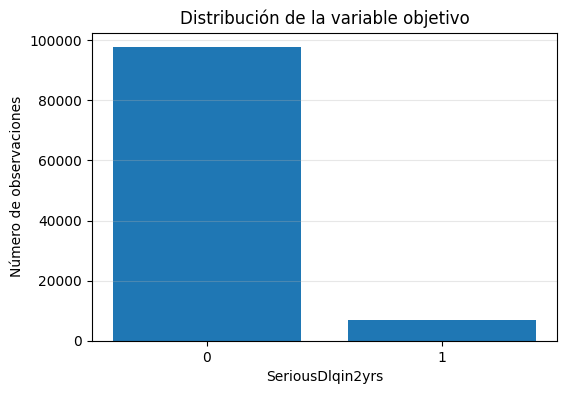

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(target_counts[TARGET].astype(str), target_counts["n"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Número de observaciones")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4. Estadísticos descriptivos iniciales

La tabla siguiente resume posición, dispersión y percentiles. En este dataset es especialmente importante mirar `p99` y `max`, porque varias variables financieras suelen tener valores extremos que deforman los histogramas.

In [12]:
def describe_numeric(df: pd.DataFrame, columns: Optional[List[str]] = None) -> pd.DataFrame:
    """
    Devuelve un resumen ampliado para variables numéricas.

    Incluye percentiles altos para detectar concentración a la izquierda y colas largas.
    """
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "variable": col,
            "n": len(s),
            "missing": df[col].isna().sum(),
            "missing_pct": 100 * df[col].isna().mean(),
            "min": s.min() if len(s) else np.nan,
            "p01": s.quantile(0.01) if len(s) else np.nan,
            "p05": s.quantile(0.05) if len(s) else np.nan,
            "p25": s.quantile(0.25) if len(s) else np.nan,
            "median": s.median() if len(s) else np.nan,
            "mean": s.mean() if len(s) else np.nan,
            "p75": s.quantile(0.75) if len(s) else np.nan,
            "p95": s.quantile(0.95) if len(s) else np.nan,
            "p99": s.quantile(0.99) if len(s) else np.nan,
            "max": s.max() if len(s) else np.nan,
            "std": s.std() if len(s) else np.nan,
            "skew": s.skew() if len(s) else np.nan,
            "kurtosis": s.kurtosis() if len(s) else np.nan,
        })

    return pd.DataFrame(rows).sort_values("variable").reset_index(drop=True)

numeric_summary_raw = describe_numeric(raw_train)
numeric_summary_raw

,variable,n,missing,missing_pct,min,p01,p05,p25,median,mean,p75,p95,p99,max,std,skew,kurtosis
0,DebtRatio,104669,0,0.0000,0.0000,0.0000,0.0050,0.1767,0.3675,355.2705,0.8747,"2,470.0000","5,008.0000","329,664.0000","2,002.5155",99.8922,"15,198.3989"
1,MonthlyIncome,84150,20519,19.6037,0.0000,0.0000,"1,300.0000","3,400.0000","5,400.0000","6,704.3697","8,250.0000","14,597.7500","25,000.0000","3,008,750.0000","15,372.4536",113.8311,"19,172.1061"
2,NumberOfDependents,101981,2688,2.5681,0.0000,0.0000,0.0000,0.0000,0.0000,0.7589,1.0000,3.0000,4.0000,13.0000,1.1150,1.5558,2.4537
3,NumberOfOpenCreditLinesAndLoans,104669,0,0.0000,0.0000,0.0000,2.0000,5.0000,8.0000,8.4621,11.0000,18.0000,24.0000,58.0000,5.1235,1.2240,3.1615
4,NumberOfTime30-59DaysPastDueNotWorse,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3997,0.0000,2.0000,4.0000,98.0000,3.9383,23.9879,590.8447
5,NumberOfTime60-89DaysPastDueNotWorse,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2185,0.0000,1.0000,2.0000,98.0000,3.8977,24.8670,620.5665
6,NumberOfTimes90DaysLate,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2444,0.0000,1.0000,3.0000,98.0000,3.9129,24.5699,610.2678
7,NumberRealEstateLoansOrLines,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0196,2.0000,3.0000,4.0000,54.0000,1.1343,3.7663,73.2144
8,RevolvingUtilizationOfUnsecuredLines,104669,0,0.0000,0.0000,0.0000,0.0000,0.0302,0.1547,6.1649,0.5588,1.0000,1.1078,"22,198.0000",218.0251,58.8569,"4,405.4525"
9,SeriousDlqin2yrs,104669,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0670,0.0000,1.0000,1.0000,1.0000,0.2501,3.4631,9.9931


Observamos que las variables
* NumberOfTime30-59DaysPastDueNotWorse
* NumberOfTime60-89DaysPastDueNotWorse
* NumberOfTimes90DaysLate
tienen un máxio de 98 que probablemente indiquen vacíos.

In [17]:
raw_train['NumberOfTime30-59DaysPastDueNotWorse'].value_counts()

NumberOfTime30-59DaysPastDueNotWorse
0     87895
1     11244
2      3224
3      1249
4       496
5       238
98      162
6        96
7        31
8        19
9         7
10        3
96        3
12        2
Name: count, dtype: int64

In [18]:
raw_train['NumberOfTime60-89DaysPastDueNotWorse'].value_counts()

NumberOfTime60-89DaysPastDueNotWorse
0     99424
1      3967
2       780
3       226
98      162
4        65
5        21
6        12
7         7
96        3
8         2
Name: count, dtype: int64

In [20]:
raw_train['NumberOfTimes90DaysLate'].value_counts()

NumberOfTimes90DaysLate
0     98880
1      3671
2      1068
3       466
4       203
98      162
5        92
6        56
7        24
9        14
8        13
10        6
13        4
11        3
96        3
15        2
14        2
Name: count, dtype: int64

Vemos que efectivamente el 98 y el 96 en estas columnas es probable que indiquen vacíos, por los que también los imputaremos, tratándolos como vacíos. Es necesario hacerlo en prod y en train.

In [22]:
# Sustituimos los valores 98 y 96 por NaN 

cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for df in [raw_train, raw_prod]:
    df[cols] = df[cols].replace(98, np.nan)
    df[cols] = df[cols].replace(96, np.nan)

In [28]:
describe_numeric(raw_train[cols])

,variable,n,missing,missing_pct,min,p01,p05,p25,median,mean,p75,p95,p99,max,std,skew,kurtosis
0,NumberOfTime30-59DaysPastDueNotWorse,104504,165,0.1576,0.0000,0.0000,0.0000,0.0000,0.0000,0.2457,0.0000,2.0000,3.0000,12.0000,0.6938,4.1913,24.7290
1,NumberOfTime60-89DaysPastDueNotWorse,104504,165,0.1576,0.0000,0.0000,0.0000,0.0000,0.0000,0.0642,0.0000,0.0000,2.0000,8.0000,0.3268,7.3872,79.1519
2,NumberOfTimes90DaysLate,104504,165,0.1576,0.0000,0.0000,0.0000,0.0000,0.0000,0.0901,0.0000,1.0000,2.0000,15.0000,0.4840,9.3547,136.2815


## 5. Análisis de valores perdidos

En este dataset los valores perdidos aparecen principalmente en variables de renta y dependientes. No deben eliminarse sin más: perderíamos muchas filas y además el hecho de que falte renta puede ser informativo.

Por eso haremos dos cosas:

1. Crear indicadores binarios de ausencia (`*_was_missing`).
2. Imputar los valores usando KNN, ajustado únicamente en construcción y aplicado después a producción.

In [32]:
def missing_report(train: pd.DataFrame, prod: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    """Crea un informe comparando missing en construcción y producción."""
    report = pd.DataFrame({
        "missing_train": train.isna().sum(),
        "missing_train_pct": 100 * train.isna().mean(),
    })

    if prod is not None:
        report["missing_prod"] = prod.isna().sum()
        report["missing_prod_pct"] = 100 * prod.isna().mean()

    return report.sort_values("missing_train_pct", ascending=False)

missing = missing_report(raw_train, raw_prod)
missing

,missing_train,missing_train_pct,missing_prod,missing_prod_pct
MonthlyIncome,20519,19.6037,8936,19.8578
NumberOfDependents,2688,2.5681,1186,2.6356
NumberOfTimes90DaysLate,165,0.1576,81,0.1800
NumberOfTime60-89DaysPastDueNotWorse,165,0.1576,81,0.1800
NumberOfTime30-59DaysPastDueNotWorse,165,0.1576,81,0.1800
SeriousDlqin2yrs,0,0.0000,45000,100.0000
RevolvingUtilizationOfUnsecuredLines,0,0.0000,0,0.0000
age,0,0.0000,0,0.0000
DebtRatio,0,0.0000,0,0.0000
NumberOfOpenCreditLinesAndLoans,0,0.0000,0,0.0000


In [34]:
# Analizamos si tener missing está asociado al target.
# Esto ayuda a decidir si debemos añadir flags de missing.
missing_effect_rows = []

for col in FEATURES:
    if raw_train[col].isna().any():
        flag = raw_train[col].isna()
        missing_effect_rows.append({
            "variable": col,
            "n_missing": flag.sum(),
            "default_rate_missing": raw_train.loc[flag, TARGET].mean(),
            "default_rate_not_missing": raw_train.loc[~flag, TARGET].mean(),
            "difference": raw_train.loc[flag, TARGET].mean() - raw_train.loc[~flag, TARGET].mean(),
        })

missing_effect = pd.DataFrame(missing_effect_rows)
missing_effect

,variable,n_missing,default_rate_missing,default_rate_not_missing,difference
0,NumberOfTime30-59DaysPastDueNotWorse,165,0.6000,0.0662,0.5338
1,MonthlyIncome,20519,0.0556,0.0698,-0.0143
2,NumberOfTimes90DaysLate,165,0.6000,0.0662,0.5338
3,NumberOfTime60-89DaysPastDueNotWorse,165,0.6000,0.0662,0.5338
4,NumberOfDependents,2688,0.0476,0.0675,-0.0199


## 6. Imputación KNN reutilizable

### Por qué KNN

La imputación KNN rellena un valor ausente buscando clientes parecidos según el resto de variables. Por ejemplo, para imputar `MonthlyIncome`, no usa una media global, sino valores de clientes con perfiles similares.

### Problema práctico

KNN depende de distancias. Si una variable está en miles de euros y otra en unidades, la variable con escala mayor domina la distancia. Por eso implementamos un imputador que:

1. Ajusta un `StandardScaler` con los datos de construcción.
2. Aplica KNN sobre variables escaladas.
3. Deshace el escalado para volver a las unidades originales.

Además, se guarda el objeto para poder aplicarlo después a producción y a cualquier scoring futuro.

In [44]:
@dataclass
class ScaledKNNImputer:
    """
    Imputador KNN con escalado interno y método explicativo.

    Además de imputar valores perdidos, permite explicar una imputación concreta
    mostrando qué filas similares se han usado como referencia.

    Importante:
    - La explicación no replica exactamente el cálculo interno de KNNImputer.
    - Para explicar una variable concreta, busca vecinos eliminando esa variable
      del cálculo de distancia.
    - Esto evita comparar usando justo la columna que estaba vacía.
    """
    columns: List[str]
    n_neighbors: int = 7
    weights: str = "distance"
    fit_sample_size: int = 10000
    random_state: int = 42

    def __post_init__(self):
        self.scaler = StandardScaler()
        self.imputer = KNNImputer(
            n_neighbors=self.n_neighbors,
            weights=self.weights,
        )
        self.fitted_ = False
        self.fit_indices_ = None
        self.fit_df_ = None
        self.train_imputed_ = None

    def fit(self, df: pd.DataFrame):
        x_all = df[self.columns].astype(float).copy()

        self.fit_df_ = df.copy()

        self.scaler.fit(x_all)

        rng = np.random.default_rng(self.random_state)

        missing_mask = x_all.isna().any(axis=1)
        missing_indices = x_all.index[missing_mask].to_numpy()
        complete_indices = x_all.index[~missing_mask].to_numpy()

        n_missing_keep = min(len(missing_indices), self.fit_sample_size // 2)
        n_complete_keep = max(self.fit_sample_size - n_missing_keep, 0)

        sampled_missing = (
            rng.choice(missing_indices, size=n_missing_keep, replace=False)
            if n_missing_keep > 0
            else np.array([], dtype=int)
        )

        sampled_complete = (
            rng.choice(
                complete_indices,
                size=min(n_complete_keep, len(complete_indices)),
                replace=False,
            )
            if len(complete_indices) > 0 and n_complete_keep > 0
            else np.array([], dtype=int)
        )

        fit_indices = np.concatenate([sampled_missing, sampled_complete])

        if len(fit_indices) == 0:
            fit_indices = x_all.index.to_numpy()

        self.fit_indices_ = fit_indices

        x_fit = x_all.loc[fit_indices]
        x_fit_scaled = self.scaler.transform(x_fit)

        self.imputer.fit(x_fit_scaled)

        self.fitted_ = True

        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self.fitted_:
            raise RuntimeError("El imputador debe ajustarse con fit antes de usar transform.")

        result = df.copy()
        result[self.columns] = result[self.columns].astype(float)

        x = result[self.columns].astype(float).copy()

        rows_with_missing = x.isna().any(axis=1)

        if rows_with_missing.any():
            x_missing = x.loc[rows_with_missing]

            x_scaled = self.scaler.transform(x_missing)
            x_imputed_scaled = self.imputer.transform(x_scaled)
            x_imputed = self.scaler.inverse_transform(x_imputed_scaled)

            result.loc[rows_with_missing, self.columns] = x_imputed

        return result

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        result = self.fit(df).transform(df)
        self.train_imputed_ = result.copy()
        return result


    def explain_imputation(
        self,
        original_df: pd.DataFrame,
        imputed_df: pd.DataFrame,
        column: str,
        row_index: Optional[int] = None,
        n_neighbors: int = 5,
        display_columns: Optional[List[str]] = None,
    ) -> pd.DataFrame:

        if not self.fitted_:
            raise RuntimeError("El imputador debe ajustarse antes de explicar imputaciones.")

        if column not in self.columns:
            raise ValueError(f"La columna {column} no está dentro de las columnas imputables.")

        if row_index is None:
            missing_rows = original_df.index[original_df[column].isna()]
            if len(missing_rows) == 0:
                raise ValueError(f"No hay valores missing originales en la columna {column}.")
            row_index = missing_rows[0]

        if not pd.isna(original_df.loc[row_index, column]):
            raise ValueError(
                f"La fila {row_index} no tenía missing en {column}. "
                "Elige una fila que realmente haya sido imputada."
            )

        col_pos = self.columns.index(column)

        # Dataset real usado por el KNNImputer durante fit
        fit_df = original_df.loc[self.fit_indices_, self.columns].astype(float).copy()

        # Fila que queremos explicar
        query_df = original_df.loc[[row_index], self.columns].astype(float).copy()

        # Escalamos igual que en el imputador
        fit_scaled = self.scaler.transform(fit_df)
        query_scaled = self.scaler.transform(query_df)

        # Distancia exacta que usa KNNImputer
        distances = nan_euclidean_distances(query_scaled, fit_scaled)[0]

        # Solo pueden imputar esta variable los vecinos que tienen valor no missing en esa columna
        valid_mask = ~np.isnan(fit_scaled[:, col_pos])

        valid_distances = distances[valid_mask]
        valid_positions = np.where(valid_mask)[0]

        # Ordenamos vecinos por distancia
        order = np.argsort(valid_distances)

        neighbor_positions = valid_positions[order[:n_neighbors]]
        neighbor_distances = distances[neighbor_positions]

        neighbors_original = fit_df.iloc[neighbor_positions].copy()

        # Valores de la columna en escala original
        neighbor_values = neighbors_original[column].to_numpy(dtype=float)

        # Valores de la columna en escala escalada
        neighbor_values_scaled = fit_scaled[neighbor_positions, col_pos]

        if self.weights == "distance":
            eps = 1e-12

            # Si hay distancia 0, KNNImputer usa solo los vecinos con distancia 0
            if np.any(neighbor_distances == 0):
                zero_mask = neighbor_distances == 0
                estimated_scaled = np.mean(neighbor_values_scaled[zero_mask])
            else:
                weights = 1 / (neighbor_distances + eps)
                estimated_scaled = np.average(neighbor_values_scaled, weights=weights)
        else:
            estimated_scaled = np.mean(neighbor_values_scaled)

        # Deshacemos el escalado SOLO de esa columna
        estimated_original = (
            estimated_scaled * self.scaler.scale_[col_pos]
            + self.scaler.mean_[col_pos]
        )

        imputed_value = imputed_df.loc[row_index, column]

        output = pd.DataFrame({
            "neighbor_rank": np.arange(1, len(neighbor_positions) + 1),
            "knn_distance": neighbor_distances,
            f"{column}_neighbor_value": neighbor_values,
        }, index=neighbors_original.index)

        if display_columns is None:
            display_columns = [c for c in self.columns if c != column][:6]

        for c in display_columns:
            if c in neighbors_original.columns and c != column:
                output[c] = neighbors_original[c]

        print("=" * 100)
        print("Explicación de imputación KNN")
        print(f"Fila imputada: {row_index}")
        print(f"Variable imputada: {column}")
        print(f"Valor original: {original_df.loc[row_index, column]}")
        print(f"Valor imputado por KNNImputer: {imputed_value:.4f}")
        print(f"Valor reconstruido desde vecinos: {estimated_original:.4f}")
        print("=" * 100)

        return output   
        

In [45]:
def add_missing_flags(train: pd.DataFrame, prod: pd.DataFrame, columns: Optional[List[str]] = None) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    """
    Añade columnas binarias indicando si el valor original era missing.

    Estas columnas se crean antes de imputar, porque después de imputar ya no sabríamos
    dónde estaban los huecos originales.
    """
    if columns is None:
        columns = [c for c in train.columns if train[c].isna().any() or prod[c].isna().any()]

    train_out = train.copy()
    prod_out = prod.copy()
    flag_cols = []

    for col in columns:
        flag_col = f"{col}_was_missing"
        train_out[flag_col] = train_out[col].isna().astype(int)
        prod_out[flag_col] = prod_out[col].isna().astype(int)
        flag_cols.append(flag_col)

    return train_out, prod_out, flag_cols

In [46]:
# Creamos copias de trabajo.
train = raw_train.copy()
prod = raw_prod.copy()


# Añadimos flags de missing usando construcción y producción.
train, prod, missing_flag_cols = add_missing_flags(train, prod,  
                                                    columns=[c for c in FEATURES if raw_train[c].isna().any() or raw_prod[c].isna().any()])

print("Flags de missing creados:", missing_flag_cols)

# Columnas que se imputan con KNN: variables explicativas originales.
impute_cols = FEATURES.copy()

knn_imputer = ScaledKNNImputer(columns=impute_cols, n_neighbors=7, weights="distance", fit_sample_size=10000, random_state=RANDOM_STATE)
train_imputed = knn_imputer.fit_transform(train)
prod_imputed = knn_imputer.transform(prod)

print("Missing tras imputación en construcción:", train_imputed[impute_cols].isna().sum().sum())
print("Missing tras imputación en producción:", prod_imputed[impute_cols].isna().sum().sum())

Flags de missing creados: ['NumberOfTime30-59DaysPastDueNotWorse_was_missing', 'MonthlyIncome_was_missing', 'NumberOfTimes90DaysLate_was_missing', 'NumberOfTime60-89DaysPastDueNotWorse_was_missing', 'NumberOfDependents_was_missing']
Missing tras imputación en construcción: 0
Missing tras imputación en producción: 0


In [52]:
# Vamos a ver algunos casos para explicar por qué esa imputación se ha hecho así. Por ejemplo, para la variable `MonthlyIncome`:

col = "MonthlyIncome"

missing_examples = train.index[train[col].isna()][:3]

for idx in missing_examples:
    explanation = knn_imputer.explain_imputation(
        original_df=train,
        imputed_df=train_imputed,
        column=col,
        row_index=idx,
        n_neighbors=7,
        display_columns=[
            "age",
            "DebtRatio",
            "RevolvingUtilizationOfUnsecuredLines",
            "NumberOfOpenCreditLinesAndLoans",
            "NumberRealEstateLoansOrLines",
            "NumberOfDependents",
        ],
    )

    display(explanation)

Explicación de imputación KNN
Fila imputada: 4
Variable imputada: MonthlyIncome
Valor original: nan
Valor imputado por KNNImputer: 3569.2968
Valor reconstruido desde vecinos: 3569.2968


,neighbor_rank,knn_distance,MonthlyIncome_neighbor_value,age,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
39699,1,0.1618,"2,916.0000",63.0000,0.1148,1.0000,2.0000,0.0000,0.0000
71865,2,0.3087,"1,240.0000",61.0000,0.4674,1.0000,2.0000,0.0000,0.0000
91569,3,0.3087,"3,800.0000",69.0000,0.0500,0.9102,2.0000,0.0000,0.0000
74521,4,0.3203,"4,558.0000",62.0000,0.0404,1.0000,1.0000,0.0000,0.0000
10916,5,0.4654,"7,783.0000",63.0000,0.1766,0.6243,4.0000,0.0000,1.0000
104605,6,0.5343,"3,100.0000",58.0000,0.0500,0.4152,2.0000,0.0000,1.0000
14480,7,0.5343,"3,342.0000",58.0000,0.0000,1.0000,2.0000,0.0000,0.0000


Explicación de imputación KNN
Fila imputada: 20
Variable imputada: MonthlyIncome
Valor original: nan
Valor imputado por KNNImputer: 4194.9840
Valor reconstruido desde vecinos: 4194.9840


,neighbor_rank,knn_distance,MonthlyIncome_neighbor_value,age,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
84511,1,0.0305,"5,000.0000",64.0000,0.0046,0.0567,1.0000,0.0000,0.0000
51505,2,0.1464,"3,417.0000",62.0000,0.1679,1.0000,1.0000,0.0000,0.0000
88988,3,0.2080,"3,083.0000",64.0000,0.0026,0.1925,2.0000,0.0000,0.0000
24338,4,0.2200,"2,168.0000",63.0000,0.0171,0.1249,2.0000,0.0000,0.0000
58647,5,0.2200,"5,134.0000",63.0000,0.0000,0.0000,2.0000,0.0000,0.0000
63150,6,0.2200,"2,971.0000",65.0000,0.0000,0.0000,2.0000,0.0000,0.0000
65503,7,0.2525,"2,883.0000",66.0000,0.1515,0.0000,2.0000,0.0000,0.0000


Explicación de imputación KNN
Fila imputada: 25
Variable imputada: MonthlyIncome
Valor original: nan
Valor imputado por KNNImputer: 2004.2155
Valor reconstruido desde vecinos: 2004.2155


,neighbor_rank,knn_distance,MonthlyIncome_neighbor_value,age,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
65470,1,0.5707,0.0000,46.0000,256.0000,0.0572,7.0000,0.0000,0.0000
16508,2,0.6770,666.0000,49.0000,0.9190,0.1205,8.0000,0.0000,0.0000
90751,3,0.6773,"3,800.0000",45.0000,0.3341,0.0127,8.0000,0.0000,0.0000
32068,4,0.6774,"2,300.0000",49.0000,0.1717,0.3100,8.0000,0.0000,0.0000
51609,5,0.6879,1.0000,43.0000,363.0000,0.3612,6.0000,0.0000,0.0000
58818,6,0.6933,"4,697.0000",47.0000,0.2561,0.1988,7.0000,0.0000,0.0000
7978,7,0.6969,"3,000.0000",46.0000,0.3266,0.8813,7.0000,0.0000,0.0000


Nota: la variable target no se puede tener en cuenta para buscar vecinos porque en el dataset de test no existe y se asignarían de diferente forma.

In [51]:
# Algunas variables deberían ser conteos enteros.
# Después de KNN pueden quedar decimales. Para mantener sentido financiero,
# redondeamos las variables de conteo y evitamos valores negativos.
# No incluimos MonthlyIncome porque es una variable continua, no un conteo.

count_cols = [
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]

for col in count_cols:
    if col in train_imputed.columns:
        train_imputed[col] = np.round(train_imputed[col]).clip(lower=0)
        prod_imputed[col] = np.round(prod_imputed[col]).clip(lower=0)

# La edad no puede ser 0 en un dataset real de crédito. No eliminamos todavía:
# lo analizamos como posible outlier o error de captura.
train_imputed[count_cols].head()

,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,59.0000,0.0000,17.0000,0.0000,2.0000,0.0000,1.0000
1,74.0000,0.0000,16.0000,0.0000,1.0000,0.0000,0.0000
2,34.0000,0.0000,9.0000,0.0000,0.0000,0.0000,0.0000
3,66.0000,0.0000,4.0000,0.0000,1.0000,0.0000,0.0000
4,65.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000


## 7. Análisis exhaustivo de valores atípicos

En variables financieras es normal encontrar colas largas. El problema es que valores extremos pueden:

- distorsionar histogramas;
- afectar a escaladores basados en media y desviación típica;
- dificultar el entrenamiento de una red neuronal;
- dominar distancias en KNN o PCA.

No todos los outliers son errores: algunos representan clientes extremos reales. Por eso primero los cuantificamos y después aplicamos un tratamiento conservador.

In [53]:
def outlier_report(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """
    Calcula indicadores de outliers por IQR y percentiles extremos.
    """
    rows = []
    for col in columns:
        s = df[col].dropna().astype(float)
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower_iqr = q1 - 1.5 * iqr
        upper_iqr = q3 + 1.5 * iqr
        p001 = s.quantile(0.001)
        p01 = s.quantile(0.01)
        p99 = s.quantile(0.99)
        p999 = s.quantile(0.999)

        rows.append({
            "variable": col,
            "min": s.min(),
            "p001": p001,
            "p01": p01,
            "q1": q1,
            "median": s.median(),
            "q3": q3,
            "p99": p99,
            "p999": p999,
            "max": s.max(),
            "iqr": iqr,
            "lower_iqr": lower_iqr,
            "upper_iqr": upper_iqr,
            "n_outliers_iqr": int(((s < lower_iqr) | (s > upper_iqr)).sum()),
            "pct_outliers_iqr": 100 * ((s < lower_iqr) | (s > upper_iqr)).mean(),
            "n_above_p99": int((s > p99).sum()),
            "pct_above_p99": 100 * (s > p99).mean(),
        })

    return pd.DataFrame(rows).sort_values("pct_outliers_iqr", ascending=False)

outliers_raw = outlier_report(train_imputed, FEATURES)
outliers_raw

,variable,min,p001,p01,q1,median,q3,p99,p999,max,iqr,lower_iqr,upper_iqr,n_outliers_iqr,pct_outliers_iqr,n_above_p99,pct_above_p99
3,DebtRatio,0.0000,0.0000,0.0000,0.1767,0.3675,0.8747,"5,008.0000","10,735.9680","329,664.0000",0.6980,-0.8704,1.9217,21884,20.9078,1046,0.9993
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,6.0000,12.0000,0.0000,0.0000,0.0000,16616,15.8748,892,0.8522
9,NumberOfDependents,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,4.0000,6.0000,13.0000,1.0000,-1.5000,2.5000,9343,8.9262,680,0.6497
6,NumberOfTimes90DaysLate,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,6.0000,15.0000,0.0000,0.0000,0.0000,5698,5.4438,891,0.8513
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,8.0000,0.0000,0.0000,0.0000,5081,4.8544,333,0.3181
4,MonthlyIncome,-0.0000,-0.0000,0.0000,"3,200.0000","5,000.0000","7,652.0000","24,687.7600","75,000.0000","3,008,750.0000","4,452.0000","-3,478.0000","14,330.0000",4654,4.4464,1047,1.0003
5,NumberOfOpenCreditLinesAndLoans,0.0000,0.0000,0.0000,5.0000,8.0000,11.0000,24.0000,34.3320,58.0000,6.0000,-4.0000,20.0000,2744,2.6216,997,0.9525
0,RevolvingUtilizationOfUnsecuredLines,0.0000,0.0000,0.0000,0.0302,0.1547,0.5588,1.1078,"1,647.6520","22,198.0000",0.5286,-0.7627,1.3517,563,0.5379,1046,0.9993
7,NumberRealEstateLoansOrLines,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,9.0000,54.0000,2.0000,-3.0000,5.0000,554,0.5293,1021,0.9755
1,age,0.0000,21.0000,24.0000,41.0000,52.0000,63.0000,87.0000,93.3320,109.0000,22.0000,8.0000,96.0000,29,0.0277,877,0.8379


### 7.1 Visualización de distribuciones reales

En los histogramas originales muchas variables aparecen pegadas a la izquierda porque existen valores máximos enormes. Para verlo bien, por cada variable mostramos:

1. Histograma completo.
2. Histograma recortado al percentil 99.
3. Histograma con escala logarítmica en el eje Y.
4. Boxplot horizontal.

Esto permite distinguir entre la distribución de la mayoría de clientes y los casos extremos.

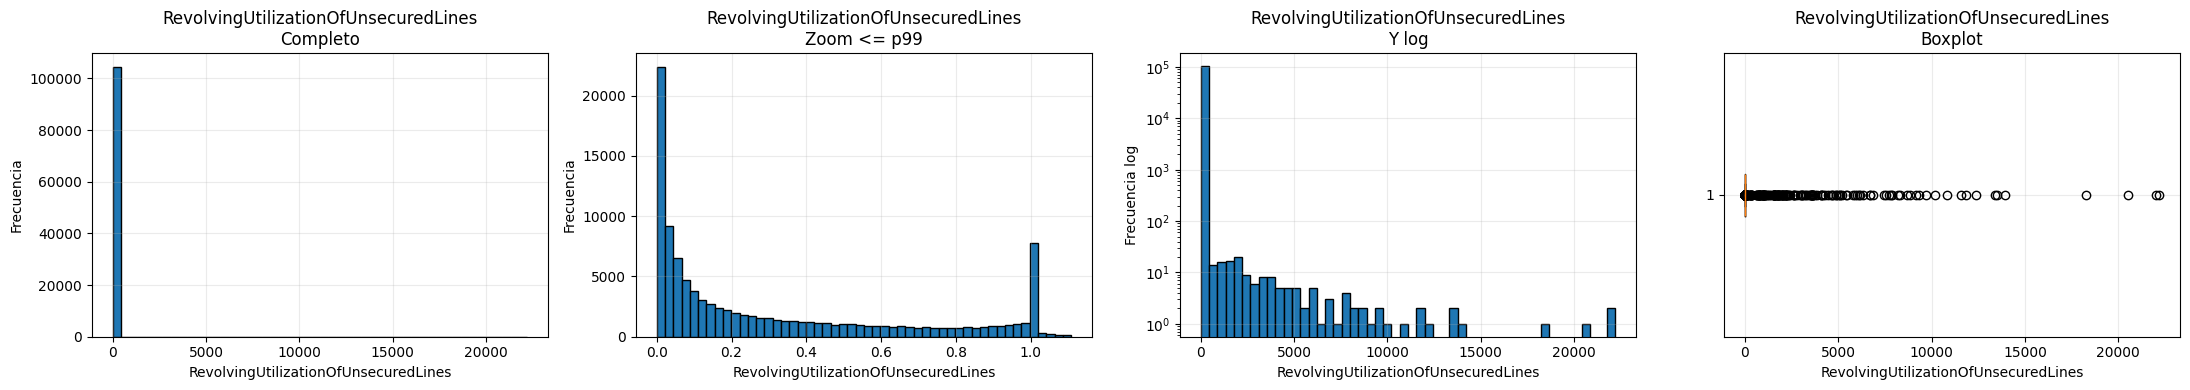

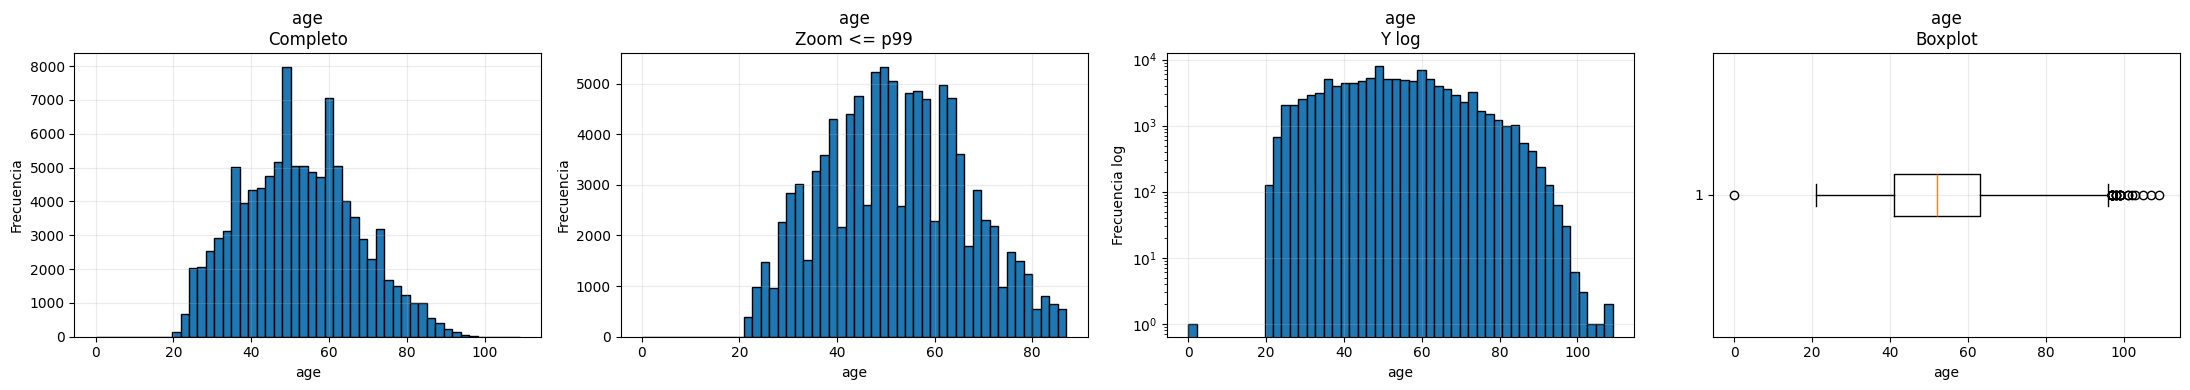

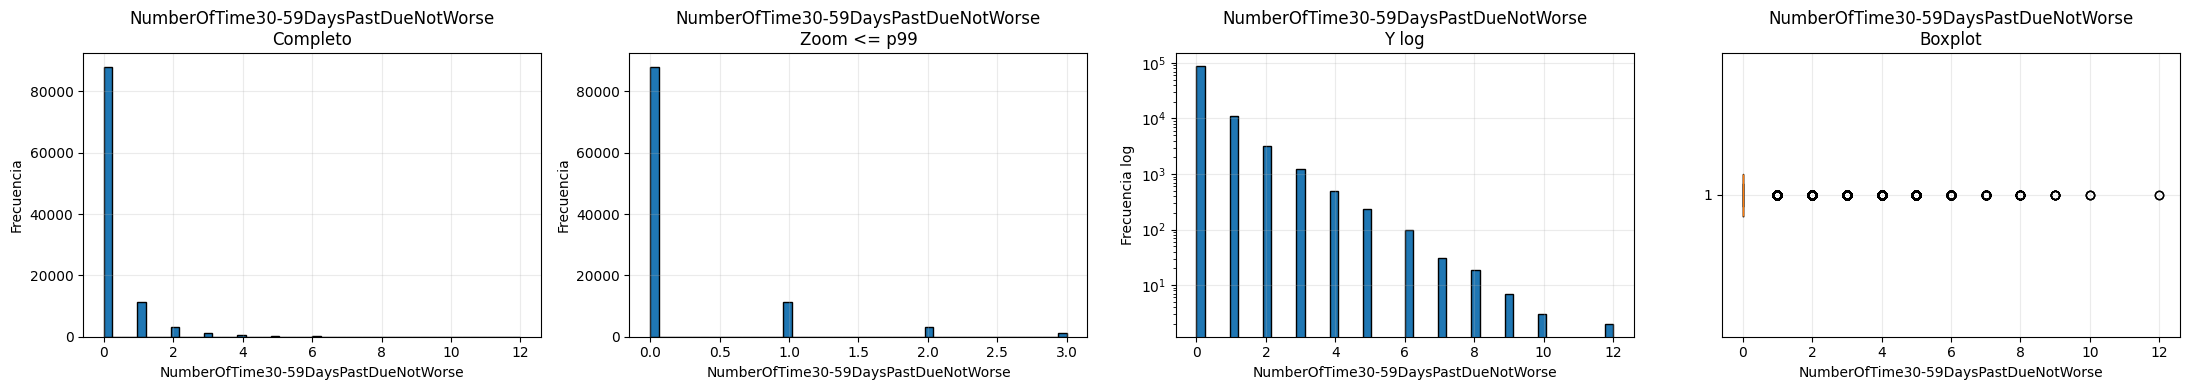

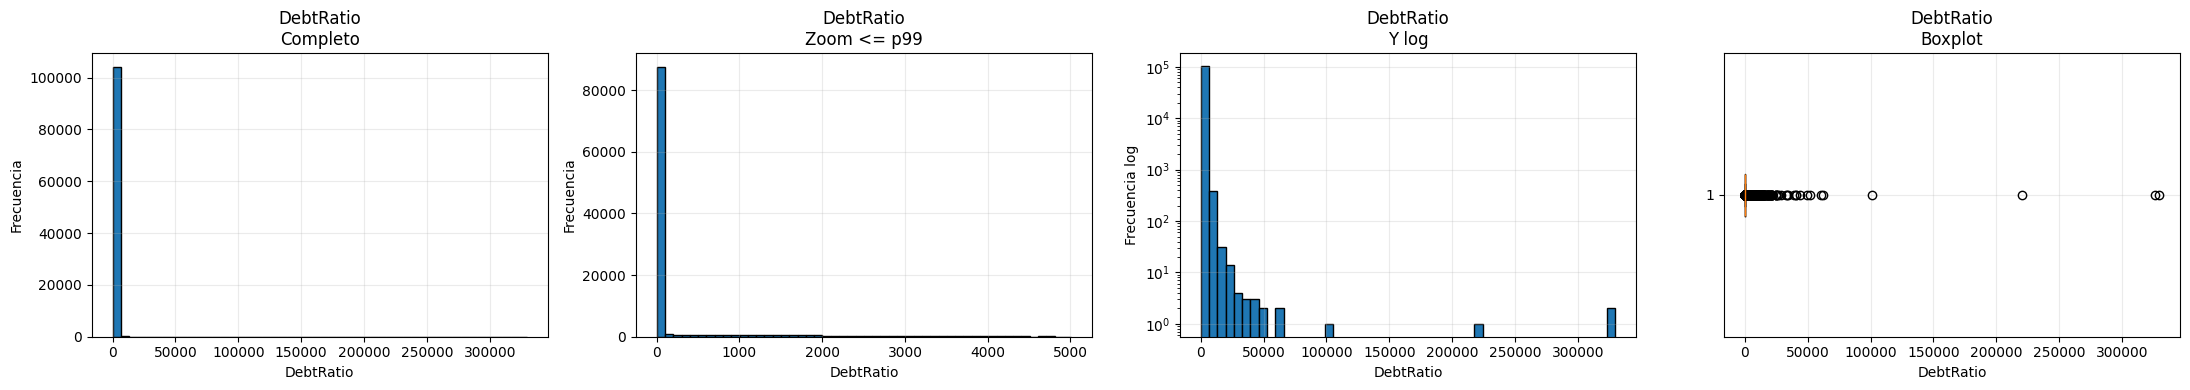

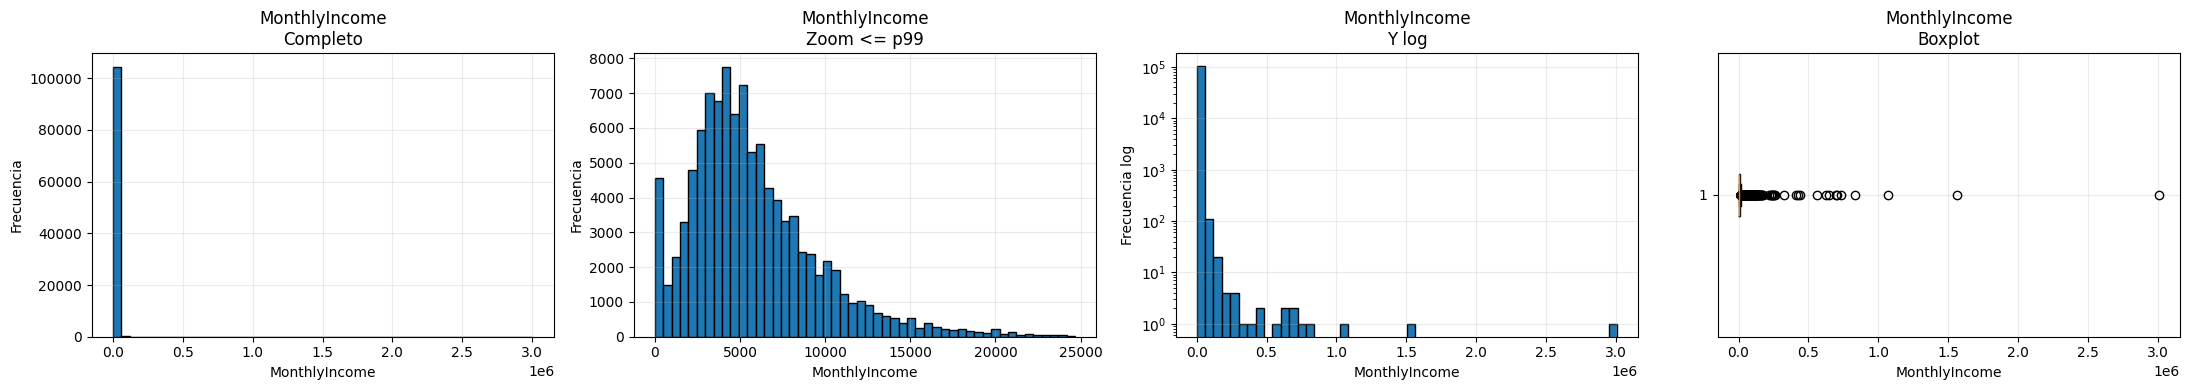

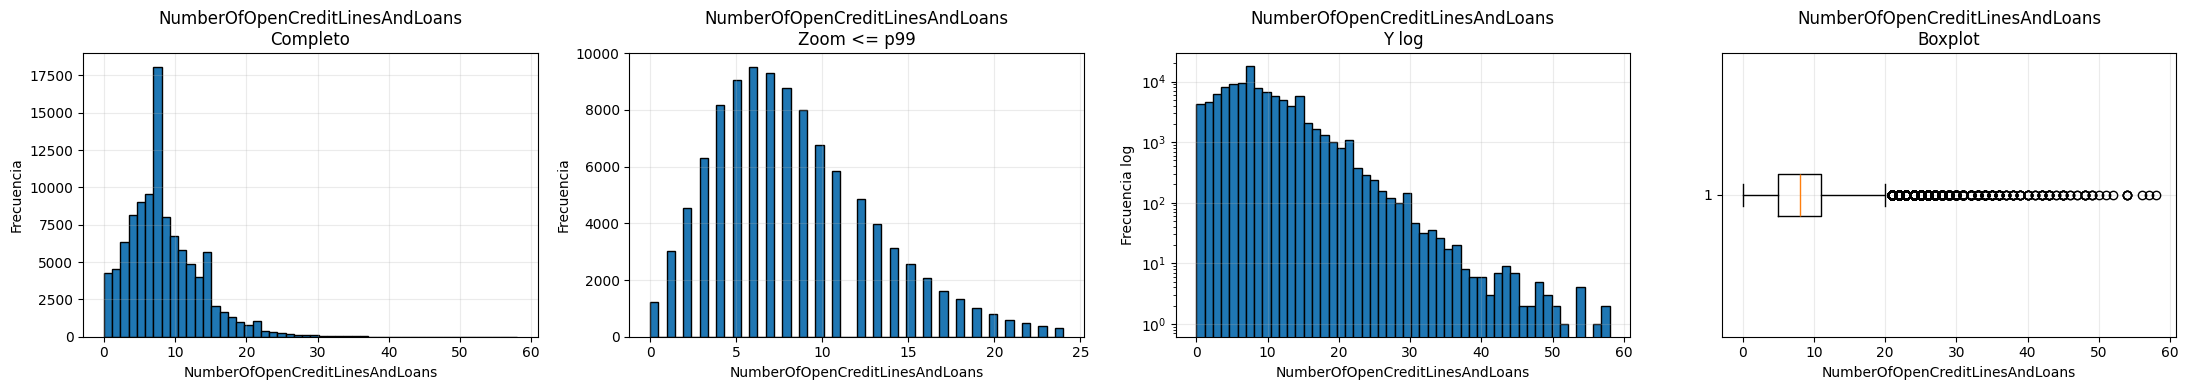

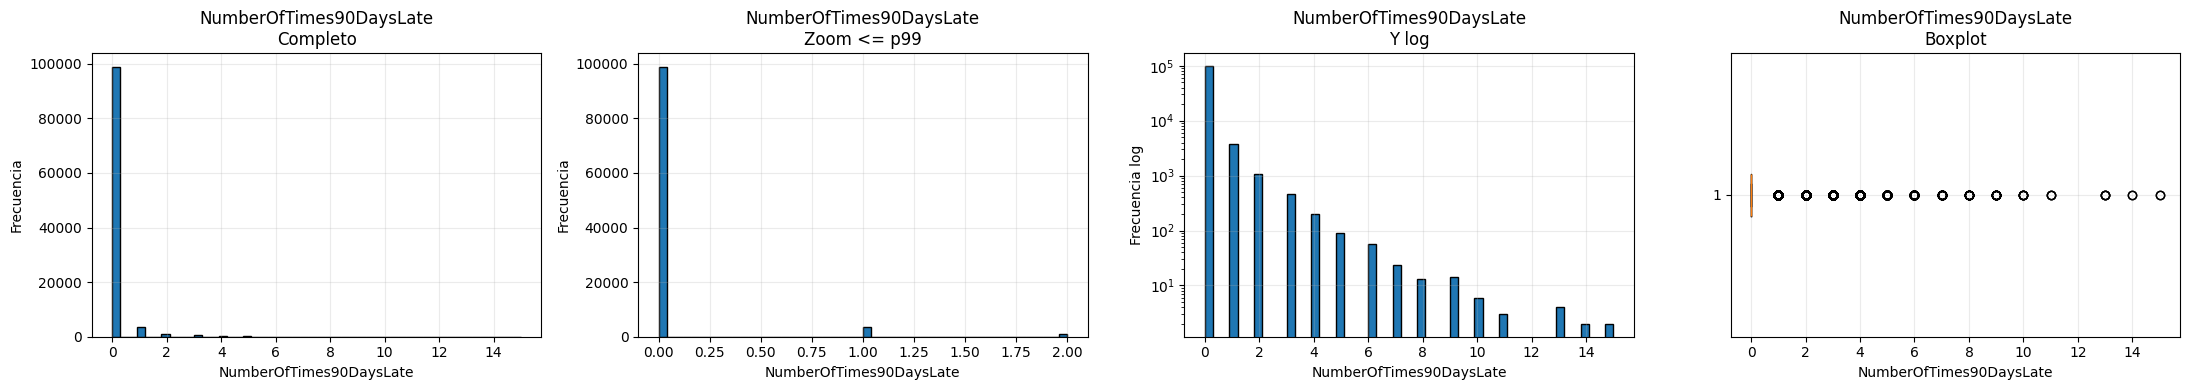

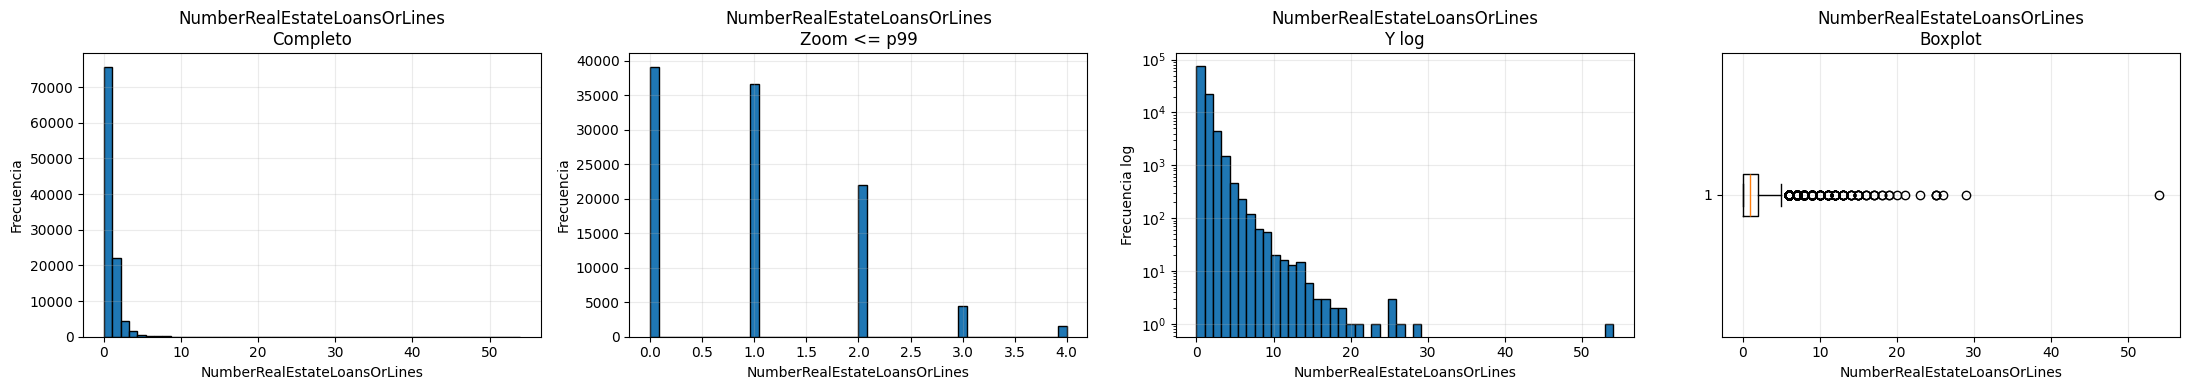

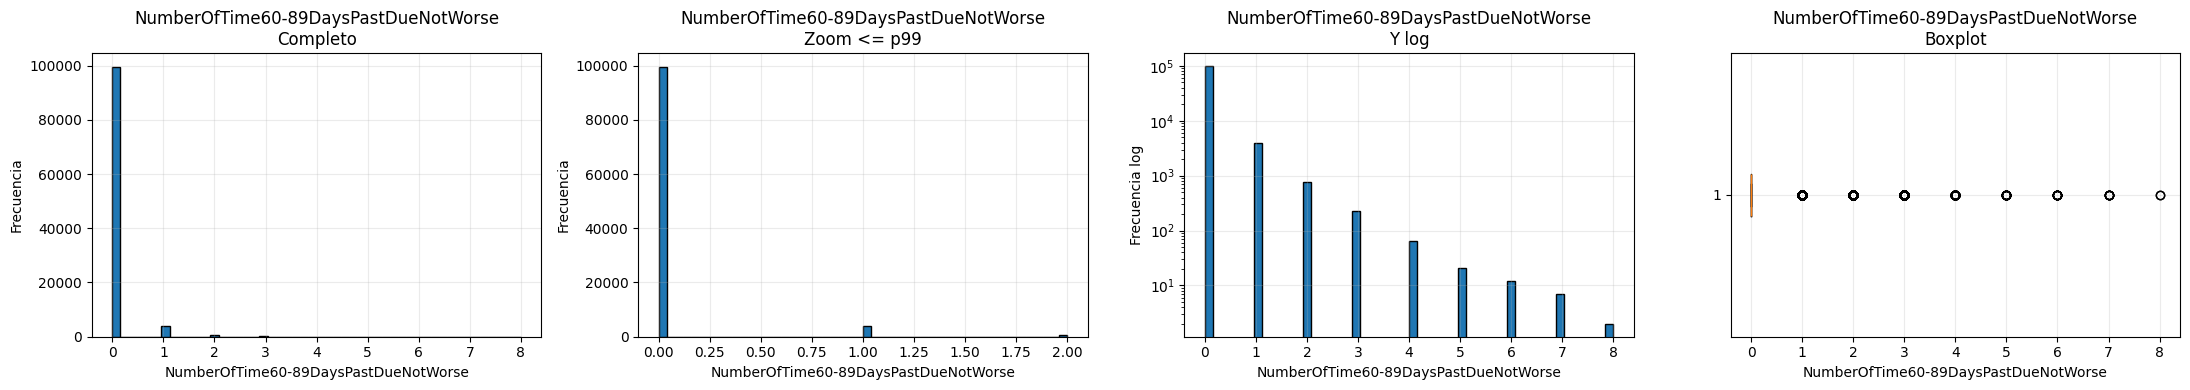

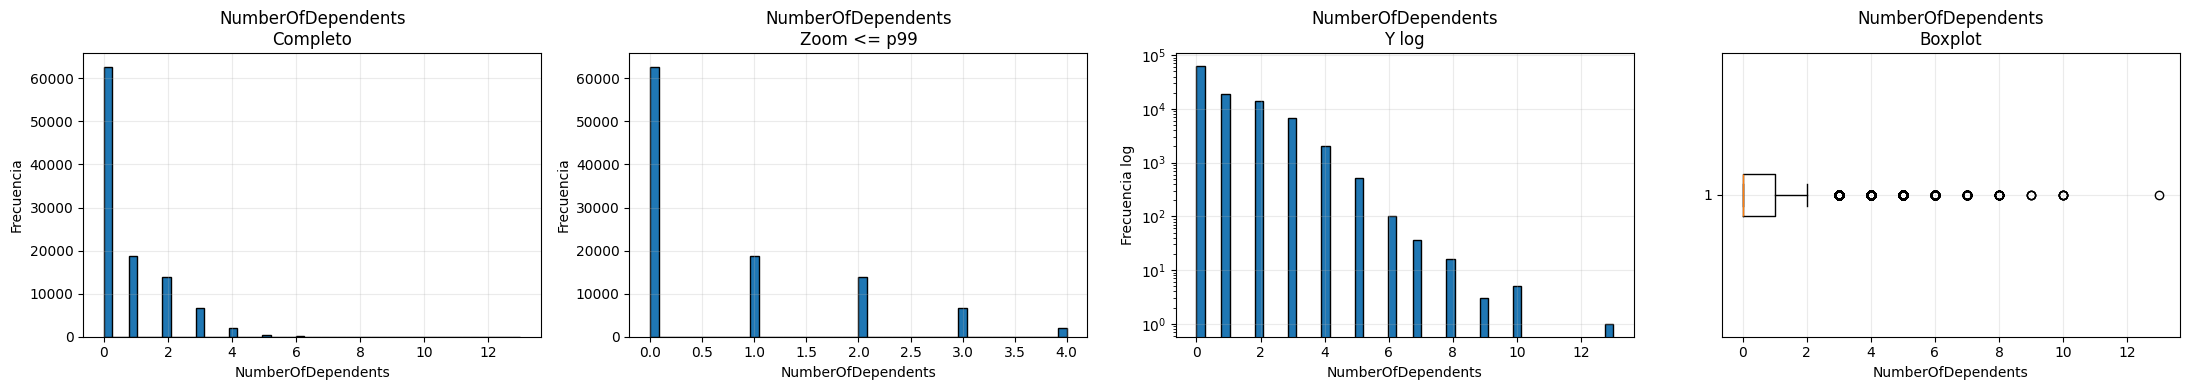

In [54]:
def plot_distribution_diagnostics(df: pd.DataFrame, columns: List[str], bins: int = 50, upper_quantile: float = 0.99):
    """
    Dibuja diagnóstico de distribución para cada variable.

    Se usa un gráfico por variable para evitar paneles enormes difíciles de leer.
    """
    for col in columns:
        s = df[col].dropna().astype(float)
        upper = s.quantile(upper_quantile)
        s_zoom = s[s <= upper]

        fig, axes = plt.subplots(1, 4, figsize=(22, 4))

        axes[0].hist(s, bins=bins, edgecolor="black")
        axes[0].set_title(f"{col}\nCompleto")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].grid(alpha=0.25)

        axes[1].hist(s_zoom, bins=bins, edgecolor="black")
        axes[1].set_title(f"{col}\nZoom <= p{int(upper_quantile * 100)}")
        axes[1].set_xlabel(col)
        axes[1].set_ylabel("Frecuencia")
        axes[1].grid(alpha=0.25)

        axes[2].hist(s, bins=bins, edgecolor="black")
        axes[2].set_yscale("log")
        axes[2].set_title(f"{col}\nY log")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel("Frecuencia log")
        axes[2].grid(alpha=0.25)

        axes[3].boxplot(s, vert=False)
        axes[3].set_title(f"{col}\nBoxplot")
        axes[3].set_xlabel(col)
        axes[3].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

# Si quieres ejecutar solo algunas variables, cambia FEATURES por una lista, por ejemplo:
# ["DebtRatio", "MonthlyIncome", "RevolvingUtilizationOfUnsecuredLines"]
plot_distribution_diagnostics(train_imputed, FEATURES)

### 7.2 Decisión de tratamiento de outliers

Para una red neuronal y un bandit contextual conviene evitar que valores extremos dominen el aprendizaje. Usaremos un tratamiento conservador:

- No eliminamos filas.
- Ajustamos límites de clipping con construcción.
- Aplicamos los mismos límites a construcción y producción.
- Usamos percentiles 0.1 % y 99.9 % para no destruir demasiada información.

Esto es una winsorización suave: reduce el impacto de extremos muy raros, pero conserva el orden y la mayoría de la variabilidad.

In [61]:
def fit_clipping_limits(
    df: pd.DataFrame,
    columns: List[str],
    lower_q: float = 0.001,
    upper_q: float = 0.999,
) -> Dict[str, Tuple[float, float]]:
    """Aprende límites de clipping a partir del dataset de construcción."""
    limits = {}
    for col in columns:
        s = df[col].dropna().astype(float)
        lower = float(s.quantile(lower_q))
        upper = float(s.quantile(upper_q))
        limits[col] = (lower, upper)
    return limits


def apply_clipping(df: pd.DataFrame, limits: Dict[str, Tuple[float, float]]) -> pd.DataFrame:
    """Aplica límites de clipping previamente ajustados."""
    out = df.copy()
    for col, (lower, upper) in limits.items():
        out[col] = out[col].clip(lower=lower, upper=upper)
    return out


# Variables sobre las que aplicamos clipping.
# Excluimos flags binarios de missing y el target.
clip_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
]
clipping_limits = fit_clipping_limits(train_imputed, clip_cols, lower_q=0.001, upper_q=0.999)

train_clipped = apply_clipping(train_imputed, clipping_limits)
prod_clipped = apply_clipping(prod_imputed, clipping_limits)

pd.DataFrame([
    {"variable": col, "lower_limit": lim[0], "upper_limit": lim[1]}
    for col, lim in clipping_limits.items()
]).sort_values("variable")

,variable,lower_limit,upper_limit
1,DebtRatio,0.0000,"10,735.9680"
2,MonthlyIncome,-0.0000,"75,000.0000"
0,RevolvingUtilizationOfUnsecuredLines,0.0000,"1,647.6520"


## 8. Feature engineering interpretativo

Creamos variables sencillas que suelen tener sentido financiero:

- `TotalPastDueEvents`: suma de retrasos de 30-59, 60-89 y 90+ días.
- `HasAnyPastDue`: indica si hubo cualquier retraso.
- `Has90DaysLate`: indica si hubo retrasos de 90+ días.
- `CreditLinesPerRealEstateLoan`: relación entre líneas abiertas totales e inmobiliarias.
- Transformaciones `log1p` para variables con colas largas.

Las variables originales se mantienen; las nuevas ayudan al modelo y también facilitan explicaciones posteriores.

In [62]:
def add_credit_features(df: pd.DataFrame) -> pd.DataFrame:
    """Añade variables derivadas de riesgo crediticio."""
    out = df.copy()

    delinquency_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]

    out["TotalPastDueEvents"] = out[delinquency_cols].sum(axis=1)
    out["HasAnyPastDue"] = (out["TotalPastDueEvents"] > 0).astype(int)
    out["Has90DaysLate"] = (out["NumberOfTimes90DaysLate"] > 0).astype(int)
    out["HasDependents"] = (out["NumberOfDependents"] > 0).astype(int)

    out["CreditLinesPerRealEstateLoan"] = (
        out["NumberOfOpenCreditLinesAndLoans"] / (1 + out["NumberRealEstateLoansOrLines"])
    )

    # log1p es log(1+x). Funciona con ceros y reduce la cola derecha.
    log_cols = [
        "RevolvingUtilizationOfUnsecuredLines",
        "DebtRatio",
        "MonthlyIncome",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberRealEstateLoansOrLines",
        "TotalPastDueEvents",
    ]

    for col in log_cols:
        safe_values = out[col].clip(lower=0)
        out[f"{col}_log1p"] = np.log1p(safe_values)

    return out

train_fe = add_credit_features(train_clipped)
prod_fe = add_credit_features(prod_clipped)

# Features finales: todas menos target.
FINAL_FEATURES = [c for c in train_fe.columns if c != TARGET]

print("Número de features finales:", len(FINAL_FEATURES))
print(FINAL_FEATURES)

Número de features finales: 26
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'NumberOfTime30-59DaysPastDueNotWorse_was_missing', 'MonthlyIncome_was_missing', 'NumberOfTimes90DaysLate_was_missing', 'NumberOfTime60-89DaysPastDueNotWorse_was_missing', 'NumberOfDependents_was_missing', 'TotalPastDueEvents', 'HasAnyPastDue', 'Has90DaysLate', 'HasDependents', 'CreditLinesPerRealEstateLoan', 'RevolvingUtilizationOfUnsecuredLines_log1p', 'DebtRatio_log1p', 'MonthlyIncome_log1p', 'NumberOfOpenCreditLinesAndLoans_log1p', 'NumberRealEstateLoansOrLines_log1p', 'TotalPastDueEvents_log1p']


## 9. Relación de variables con la variable objetivo

Para variables numéricas, una forma útil de entender su relación con el riesgo es calcular la tasa de default por deciles. Así se ve si el riesgo aumenta o disminuye de forma ordenada.

Esta sección no es modelado todavía. Es análisis descriptivo para entender qué puede aprender el modelo.

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 0.00321]",10467,0.0261,0.0000,0.0032,2.6082
1,"(0.00321, 0.0194]",10467,0.0143,0.0032,0.0194,1.4331
2,"(0.0194, 0.0437]",10467,0.0133,0.0194,0.0437,1.3280
3,"(0.0437, 0.0837]",10467,0.0190,0.0437,0.0837,1.9012
4,"(0.0837, 0.155]",10467,0.0241,0.0837,0.1547,2.4076
5,"(0.155, 0.271]",10466,0.0352,0.1547,0.2711,3.5161
6,"(0.271, 0.446]",10467,0.0508,0.2712,0.4460,5.0826
7,"(0.446, 0.698]",10467,0.0872,0.4460,0.6978,8.7227
8,"(0.698, 0.979]",10467,0.1653,0.6979,0.9790,16.5281
9,"(0.979, 1647.652]",10467,0.2349,0.9790,"1,647.6520",23.4929


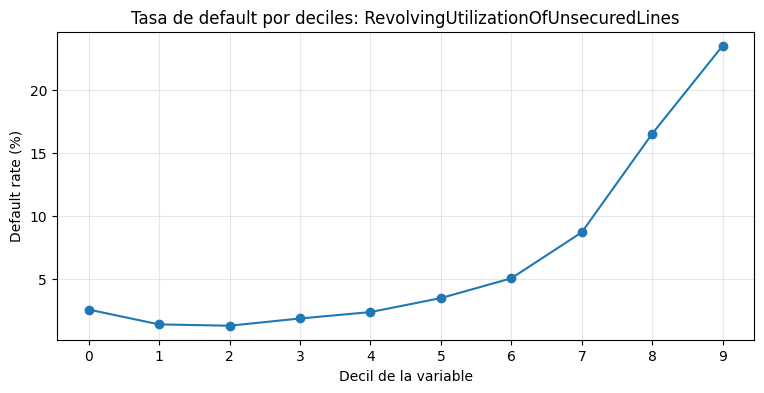

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 33.0]",11937,0.1150,0.0000,33.0000,11.5021
1,"(33.0, 39.0]",10514,0.0946,34.0000,39.0000,9.4636
2,"(39.0, 44.0]",11063,0.0894,40.0000,44.0000,8.9397
3,"(44.0, 48.0]",10274,0.0808,45.0000,48.0000,8.0786
4,"(48.0, 52.0]",10376,0.0757,49.0000,52.0000,7.5655
5,"(52.0, 56.0]",9924,0.0635,53.0000,56.0000,6.3482
6,"(56.0, 60.0]",9293,0.0497,57.0000,60.0000,4.9715
7,"(60.0, 65.0]",11558,0.0407,61.0000,65.0000,4.0664
8,"(65.0, 72.0]",9890,0.0269,66.0000,72.0000,2.6896
9,"(72.0, 109.0]",9840,0.0218,73.0000,109.0000,2.1850


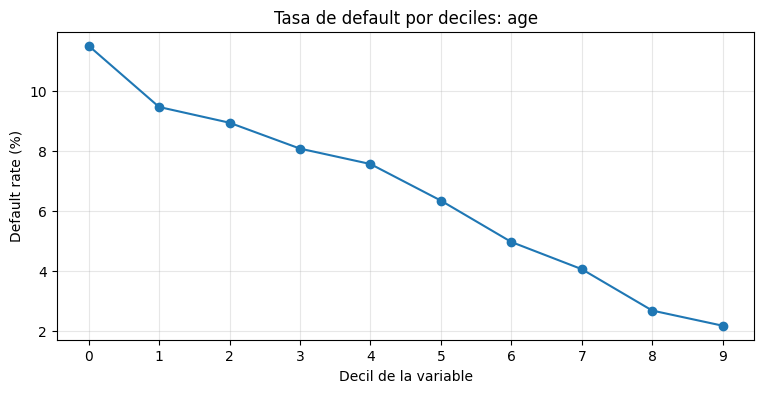

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,88053,0.0413,0.0000,0.0000,4.1293
1,1.0000,11251,0.1484,1.0000,1.0000,14.8431
2,2.0000,3224,0.2736,2.0000,2.0000,27.3573
3,3.0000,1249,0.3555,3.0000,3.0000,35.5484
4,4.0000,496,0.4093,4.0000,4.0000,40.9274
5,5.0000,238,0.4244,5.0000,5.0000,42.4370
6,6.0000,96,0.5104,6.0000,6.0000,51.0417
7,7.0000,31,0.5484,7.0000,7.0000,54.8387
8,8.0000,19,0.3158,8.0000,8.0000,31.5789
9,9.0000,7,0.4286,9.0000,9.0000,42.8571


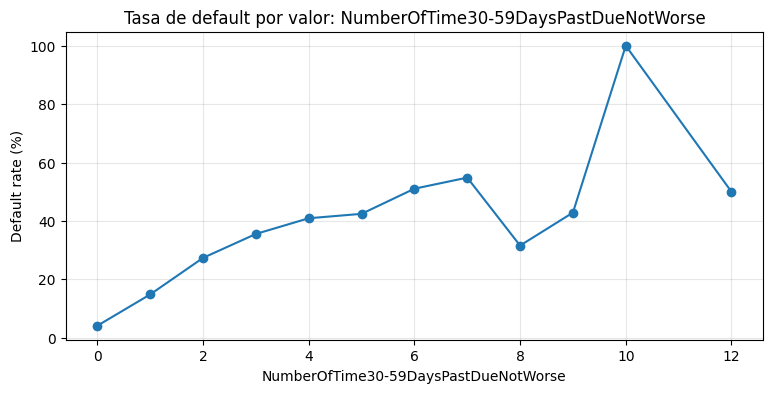

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 0.0343]",10467,0.0559,0.0000,0.0343,5.5890
1,"(0.0343, 0.136]",10467,0.0717,0.0343,0.1361,7.1654
2,"(0.136, 0.215]",10467,0.0610,0.1361,0.2150,6.1049
3,"(0.215, 0.288]",10467,0.0535,0.2151,0.2881,5.3501
4,"(0.288, 0.367]",10467,0.0536,0.2881,0.3675,5.3597
5,"(0.367, 0.468]",10466,0.0681,0.3675,0.4675,6.8125
6,"(0.468, 0.651]",10467,0.0827,0.4675,0.6506,8.2736
7,"(0.651, 4.0]",10525,0.1140,0.6506,4.0000,11.4014
8,"(4.0, 1288.0]",10411,0.0605,4.0045,"1,288.0000",6.0513
9,"(1288.0, 10735.968]",10465,0.0488,"1,289.0000","10,735.9680",4.8829


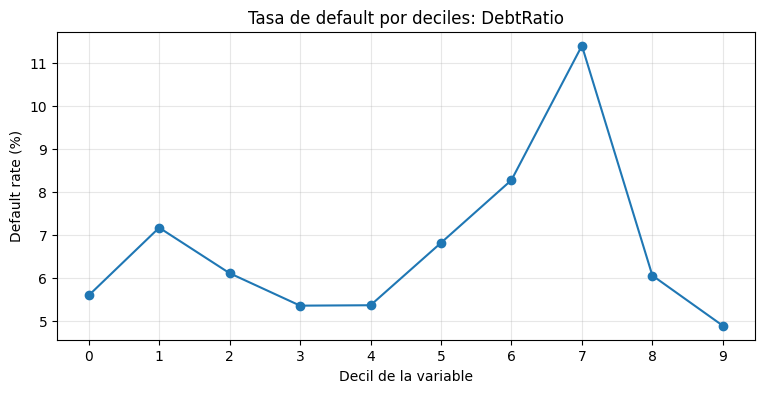

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.0010000000009090001, 1800.0]",10666,0.0720,-0.0000,"1,800.0000",7.2005
1,"(1800.0, 2816.131]",10268,0.0959,"1,800.0008","2,816.0000",9.5929
2,"(2816.131, 3574.0]",10471,0.0899,"2,816.2183","3,574.0000",8.9867
3,"(3574.0, 4283.394]",10463,0.0760,"3,574.5499","4,283.3214",7.5982
4,"(4283.394, 5000.0]",10865,0.0686,"4,283.6866","5,000.0000",6.8569
5,"(5000.0, 5917.0]",10071,0.0629,"5,000.5732","5,917.0000",6.2854
6,"(5917.0, 7000.0]",11146,0.0598,"5,918.0000","7,000.0000",5.9752
7,"(7000.0, 8475.4]",9785,0.0523,"7,000.2581","8,475.0000",5.2325
8,"(8475.4, 10937.0]",10469,0.0480,"8,476.0000","10,937.0000",4.8047
9,"(10937.0, 75000.0]",10465,0.0446,"10,938.0000","75,000.0000",4.4625


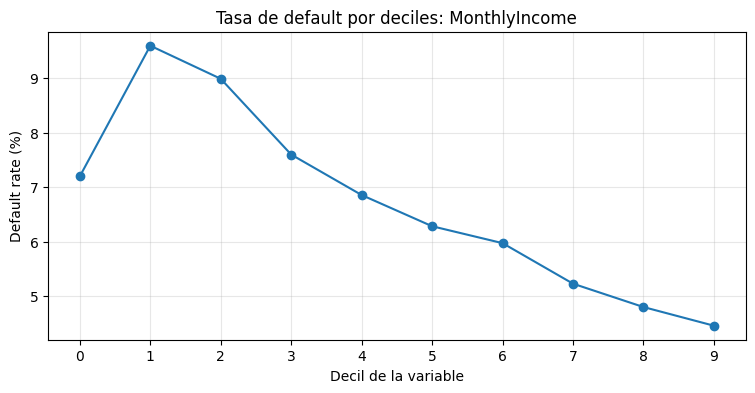

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 3.0]",15099,0.1081,0.0000,3.0000,10.8087
1,"(3.0, 4.0]",8178,0.0654,4.0000,4.0000,6.5419
2,"(4.0, 5.0]",9041,0.0653,5.0000,5.0000,6.5258
3,"(5.0, 7.0]",18823,0.0556,6.0000,7.0000,5.5570
4,"(7.0, 8.0]",8793,0.0478,8.0000,8.0000,4.7765
5,"(8.0, 9.0]",7991,0.0564,9.0000,9.0000,5.6438
6,"(9.0, 10.0]",6752,0.0607,10.0000,10.0000,6.0723
7,"(10.0, 12.0]",10717,0.0586,11.0000,12.0000,5.8598
8,"(12.0, 15.0]",9685,0.0659,13.0000,15.0000,6.5875
9,"(15.0, 58.0]",9590,0.0693,16.0000,58.0000,6.9343


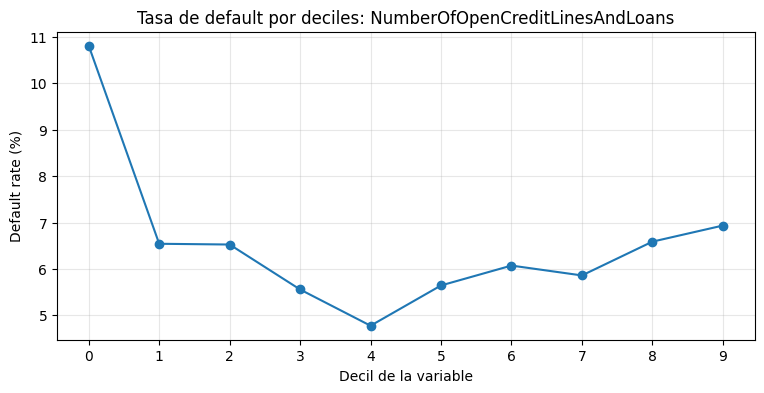

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,98971,0.0470,0.0000,0.0000,4.6983
1,1.0000,3730,0.3391,1.0000,1.0000,33.9142
2,2.0000,1077,0.5051,2.0000,2.0000,50.5107
3,3.0000,472,0.5869,3.0000,3.0000,58.6864
4,4.0000,203,0.6749,4.0000,4.0000,67.4877
5,5.0000,92,0.6413,5.0000,5.0000,64.1304
6,6.0000,56,0.6250,6.0000,6.0000,62.5000
7,7.0000,24,0.7917,7.0000,7.0000,79.1667
8,8.0000,13,0.6923,8.0000,8.0000,69.2308
9,9.0000,14,0.7143,9.0000,9.0000,71.4286


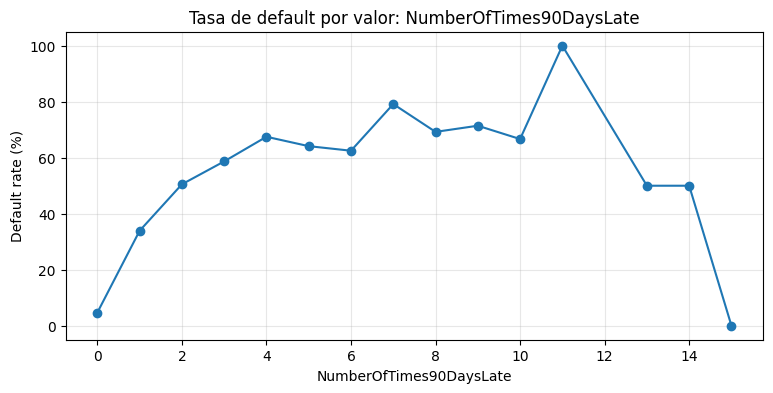

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 1.0]",75716,0.0684,0.0000,1.0000,6.8400
1,"(1.0, 2.0]",21976,0.0566,2.0000,2.0000,5.6562
2,"(2.0, 54.0]",6977,0.0850,3.0000,54.0000,8.4994


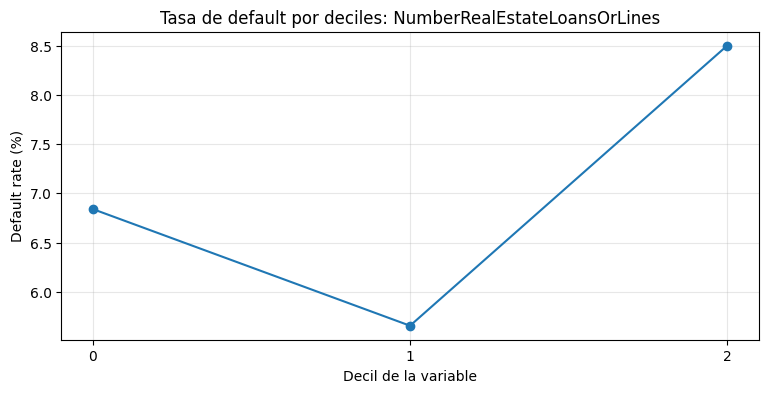

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,99588,0.0518,0.0000,0.0000,5.1844
1,1.0000,3968,0.3180,1.0000,1.0000,31.8044
2,2.0000,780,0.4987,2.0000,2.0000,49.8718
3,3.0000,226,0.5796,3.0000,3.0000,57.9646
4,4.0000,65,0.6308,4.0000,4.0000,63.0769
5,5.0000,21,0.6190,5.0000,5.0000,61.9048
6,6.0000,12,0.8333,6.0000,6.0000,83.3333
7,7.0000,7,0.7143,7.0000,7.0000,71.4286
8,8.0000,2,0.5000,8.0000,8.0000,50.0000


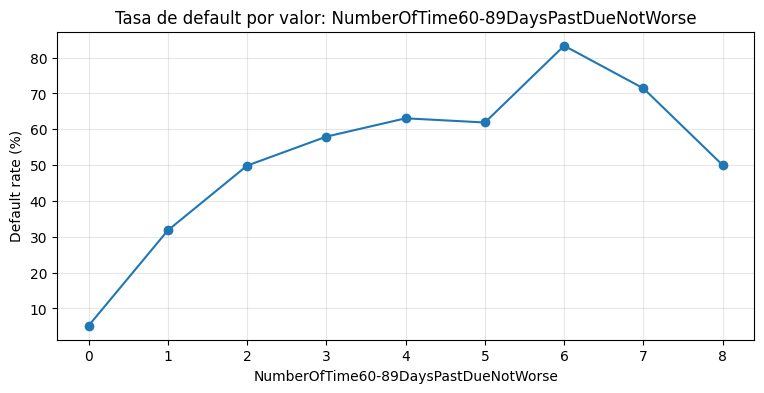

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,62718,0.0577,0.0000,0.0000,5.7671
1,1.0000,18842,0.0756,1.0000,1.0000,7.5629
2,2.0000,13766,0.0806,2.0000,2.0000,8.0633
3,3.0000,6651,0.0866,3.0000,3.0000,8.6604
4,4.0000,2012,0.1064,4.0000,4.0000,10.6362
5,5.0000,515,0.0971,5.0000,5.0000,9.7087
6,6.0000,103,0.1650,6.0000,6.0000,16.5049
7,7.0000,37,0.1351,7.0000,7.0000,13.5135
8,8.0000,16,0.0625,8.0000,8.0000,6.2500
9,9.0000,3,0.0000,9.0000,9.0000,0.0000


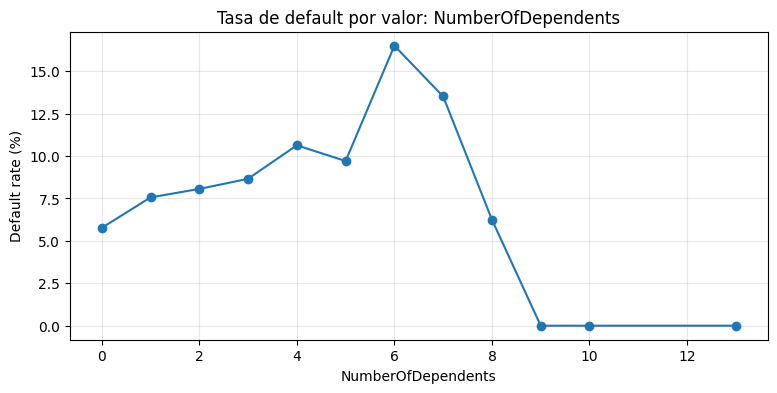

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,104504,0.0662,0,0,6.6179
1,1,165,0.6000,1,1,60.0000


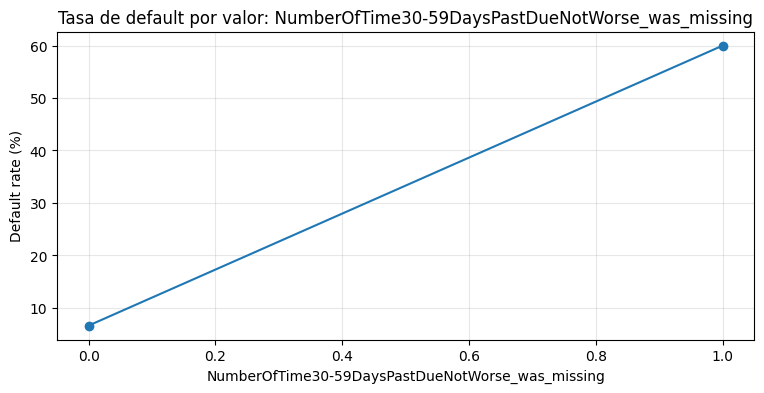

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,84150,0.0698,0,0,6.9816
1,1,20519,0.0556,1,1,5.5558


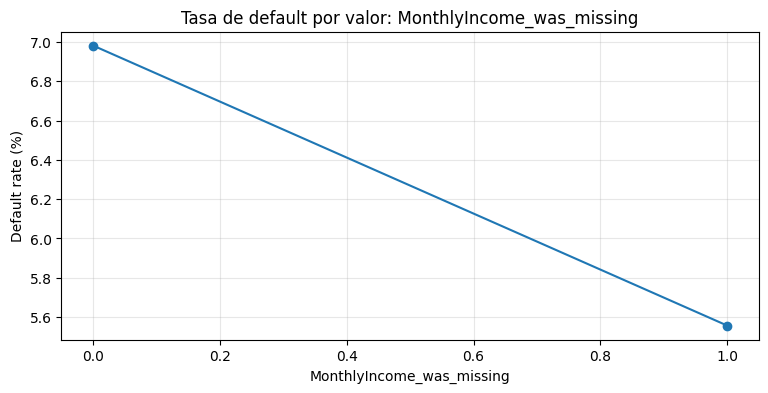

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,104504,0.0662,0,0,6.6179
1,1,165,0.6000,1,1,60.0000


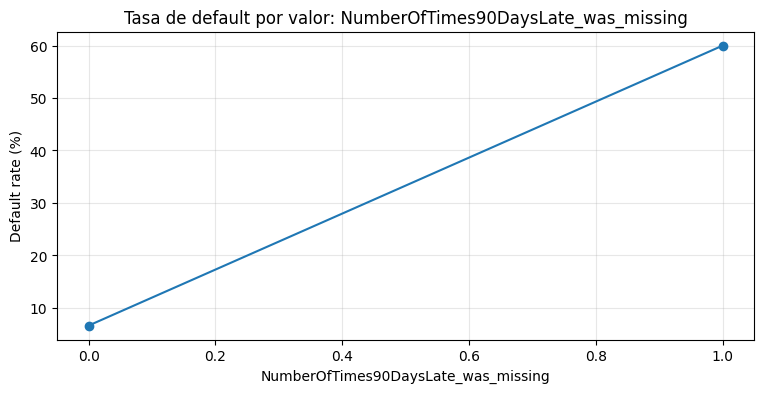

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,104504,0.0662,0,0,6.6179
1,1,165,0.6000,1,1,60.0000


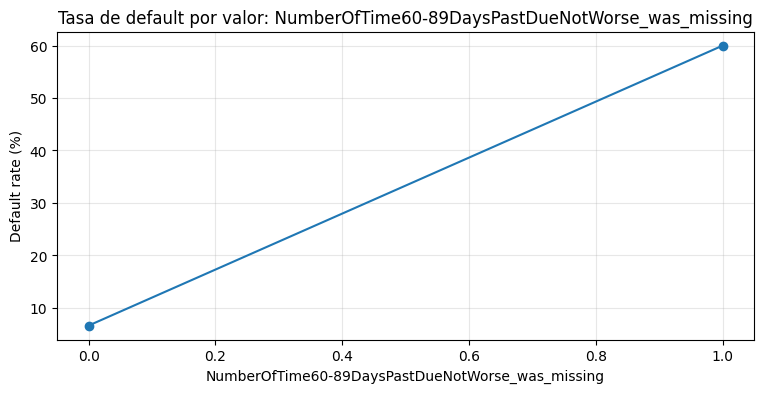

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,101981,0.0675,0,0,6.7532
1,1,2688,0.0476,1,1,4.7619


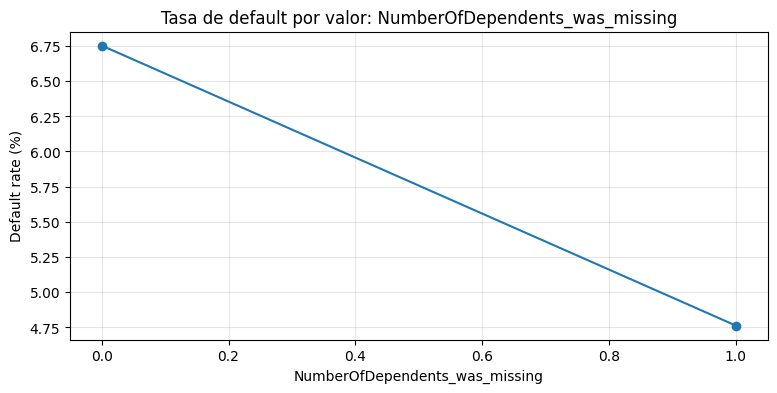

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,83559,0.0280,0.0000,0.0000,2.7956
1,1.0000,12101,0.1241,1.0000,1.0000,12.4122
2,2.0000,4183,0.2441,2.0000,2.0000,24.4083
3,3.0000,2053,0.3517,3.0000,3.0000,35.1680
4,4.0000,1114,0.4228,4.0000,4.0000,42.2801
5,5.0000,629,0.5262,5.0000,5.0000,52.6232
6,6.0000,426,0.5728,6.0000,6.0000,57.2770
7,7.0000,266,0.6203,7.0000,7.0000,62.0301
8,8.0000,130,0.6000,8.0000,8.0000,60.0000
9,9.0000,79,0.7089,9.0000,9.0000,70.8861


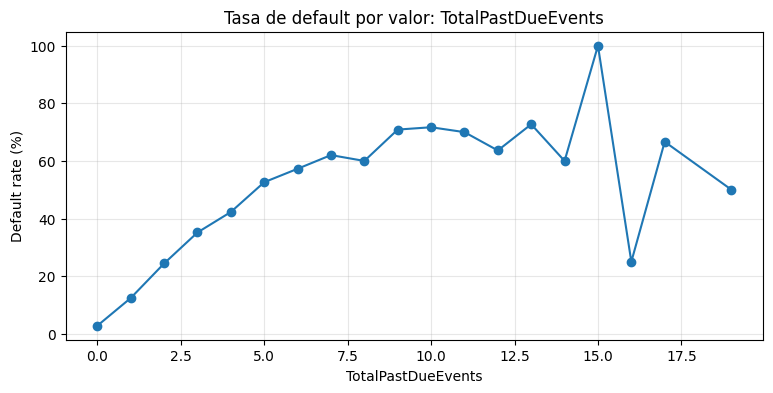

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,83559,0.0280,0,0,2.7956
1,1,21110,0.2216,1,1,22.1649


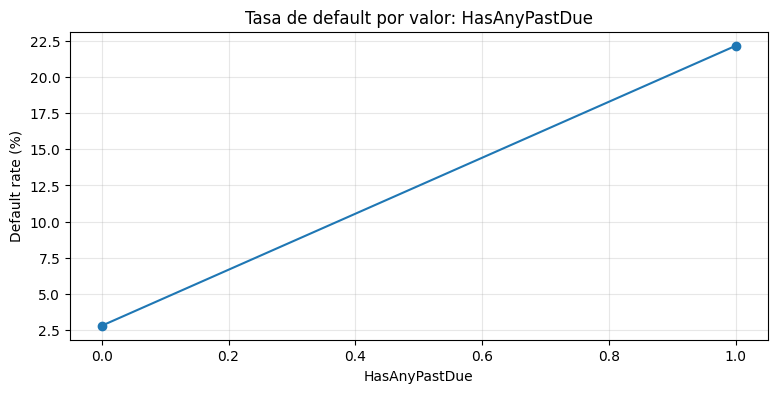

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,98971,0.0470,0,0,4.6983
1,1,5698,0.4151,1,1,41.5058


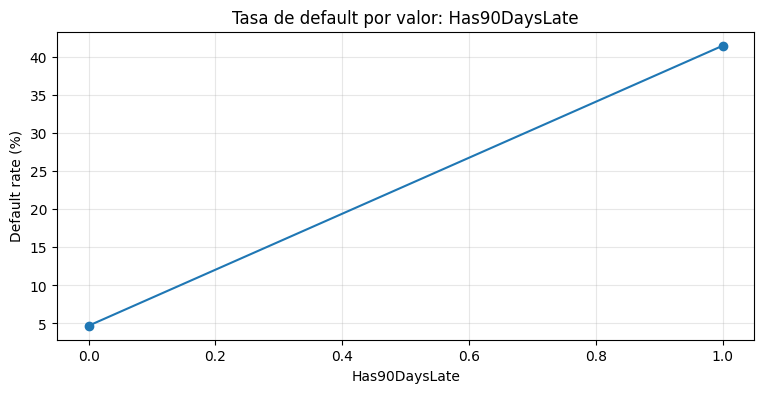

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0,62718,0.0577,0,0,5.7671
1,1,41951,0.0810,1,1,8.0999


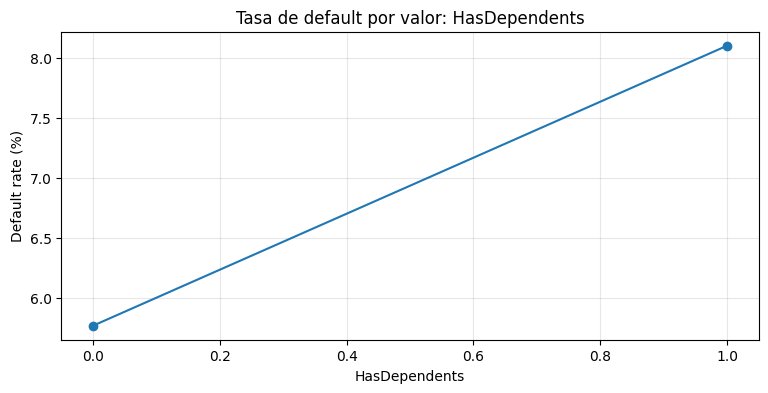

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 2.0]",19213,0.0950,0.0000,2.0000,9.5040
1,"(2.0, 2.333]",2722,0.0602,2.0714,2.3333,6.0250
2,"(2.333, 3.0]",17648,0.0600,2.3571,3.0000,6.0007
3,"(3.0, 3.333]",2405,0.0590,3.1000,3.3333,5.9044
4,"(3.333, 4.0]",16356,0.0560,3.3750,4.0000,5.6004
5,"(4.0, 4.5]",4879,0.0531,4.1429,4.5000,5.3085
6,"(4.5, 5.5]",12131,0.0636,4.6000,5.5000,6.3556
7,"(5.5, 6.5]",8624,0.0602,5.6000,6.5000,6.0181
8,"(6.5, 9.0]",12571,0.0649,6.5714,9.0000,6.4911
9,"(9.0, 56.0]",8120,0.0669,9.3333,56.0000,6.6872


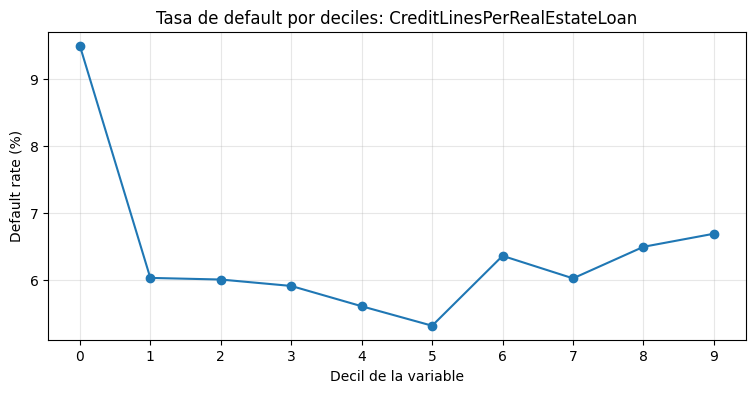

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 0.00321]",10467,0.0261,0.0000,0.0032,2.6082
1,"(0.00321, 0.0193]",10467,0.0143,0.0032,0.0193,1.4331
2,"(0.0193, 0.0428]",10467,0.0133,0.0193,0.0428,1.3280
3,"(0.0428, 0.0804]",10467,0.0190,0.0428,0.0804,1.9012
4,"(0.0804, 0.144]",10467,0.0241,0.0804,0.1438,2.4076
5,"(0.144, 0.24]",10466,0.0352,0.1439,0.2399,3.5161
6,"(0.24, 0.369]",10467,0.0508,0.2399,0.3688,5.0826
7,"(0.369, 0.529]",10467,0.0872,0.3688,0.5293,8.7227
8,"(0.529, 0.683]",10467,0.1653,0.5294,0.6826,16.5281
9,"(0.683, 7.408]",10467,0.2349,0.6826,7.4077,23.4929


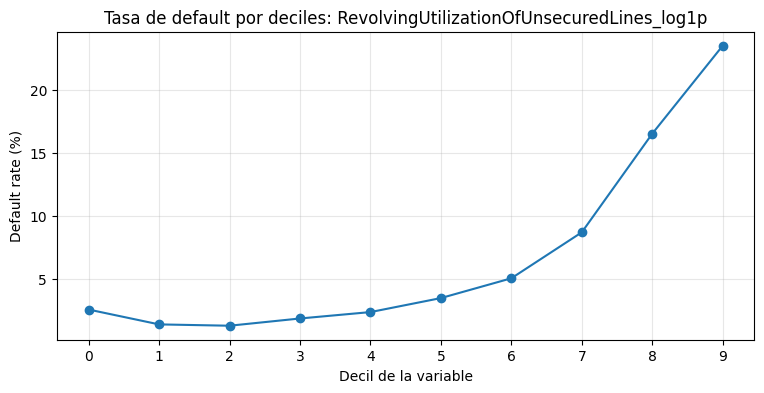

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 0.0337]",10467,0.0559,0.0000,0.0337,5.5890
1,"(0.0337, 0.128]",10467,0.0717,0.0337,0.1276,7.1654
2,"(0.128, 0.195]",10467,0.0610,0.1276,0.1948,6.1049
3,"(0.195, 0.253]",10467,0.0535,0.1948,0.2531,5.3501
4,"(0.253, 0.313]",10467,0.0536,0.2532,0.3130,5.3597
5,"(0.313, 0.384]",10466,0.0681,0.3130,0.3836,6.8125
6,"(0.384, 0.501]",10467,0.0827,0.3836,0.5011,8.2736
7,"(0.501, 1.609]",10525,0.1140,0.5011,1.6094,11.4014
8,"(1.609, 7.162]",10411,0.0605,1.6103,7.1616,6.0513
9,"(7.162, 9.281]",10465,0.0488,7.1624,9.2814,4.8829


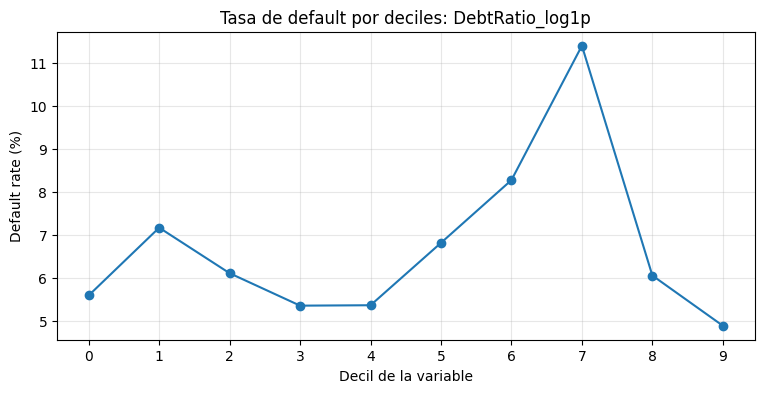

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 7.496]",10666,0.0720,0.0000,7.4961,7.2005
1,"(7.496, 7.943]",10268,0.0959,7.4961,7.9434,9.5929
2,"(7.943, 8.182]",10471,0.0899,7.9435,8.1817,8.9867
3,"(8.182, 8.363]",10463,0.0760,8.1819,8.3627,7.5982
4,"(8.363, 8.517]",10865,0.0686,8.3628,8.5174,6.8569
5,"(8.517, 8.686]",10071,0.0629,8.5175,8.6858,6.2854
6,"(8.686, 8.854]",11146,0.0598,8.6859,8.8538,5.9752
7,"(8.854, 9.045]",9785,0.0523,8.8538,9.0450,5.2325
8,"(9.045, 9.3]",10469,0.0480,9.0451,9.3000,4.8047
9,"(9.3, 11.225]",10465,0.0446,9.3001,11.2253,4.4625


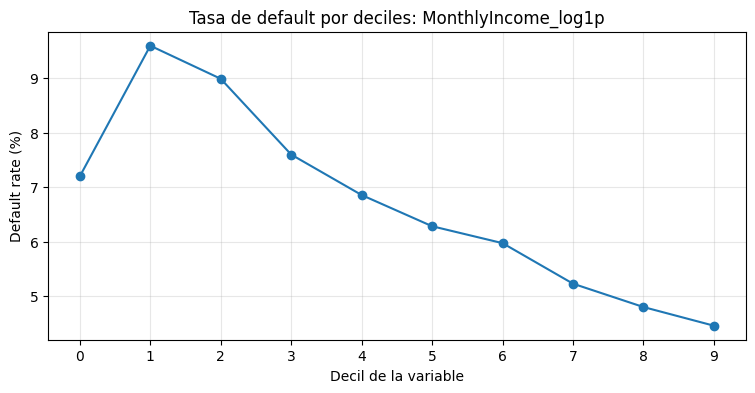

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 1.386]",15099,0.1081,0.0000,1.3863,10.8087
1,"(1.386, 1.609]",8178,0.0654,1.6094,1.6094,6.5419
2,"(1.609, 1.792]",9041,0.0653,1.7918,1.7918,6.5258
3,"(1.792, 2.079]",18823,0.0556,1.9459,2.0794,5.5570
4,"(2.079, 2.197]",8793,0.0478,2.1972,2.1972,4.7765
5,"(2.197, 2.303]",7991,0.0564,2.3026,2.3026,5.6438
6,"(2.303, 2.398]",6752,0.0607,2.3979,2.3979,6.0723
7,"(2.398, 2.565]",10717,0.0586,2.4849,2.5649,5.8598
8,"(2.565, 2.773]",9685,0.0659,2.6391,2.7726,6.5875
9,"(2.773, 4.078]",9590,0.0693,2.8332,4.0775,6.9343


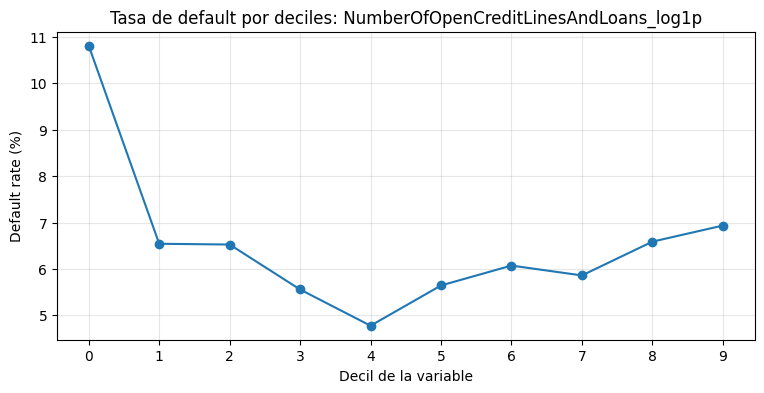

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,"(-0.001, 0.693]",75716,0.0684,0.0000,0.6931,6.8400
1,"(0.693, 1.099]",21976,0.0566,1.0986,1.0986,5.6562
2,"(1.099, 4.007]",6977,0.0850,1.3863,4.0073,8.4994


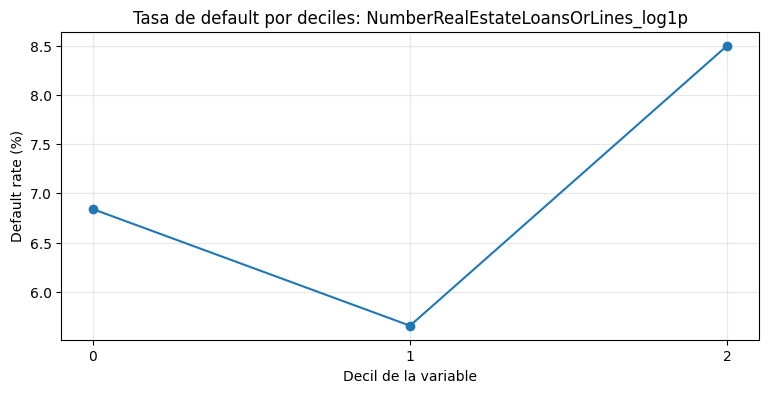

,bin,n,default_rate,feature_min,feature_max,default_rate_pct
0,0.0000,83559,0.0280,0.0000,0.0000,2.7956
1,0.6931,12101,0.1241,0.6931,0.6931,12.4122
2,1.0986,4183,0.2441,1.0986,1.0986,24.4083
3,1.3863,2053,0.3517,1.3863,1.3863,35.1680
4,1.6094,1114,0.4228,1.6094,1.6094,42.2801
5,1.7918,629,0.5262,1.7918,1.7918,52.6232
6,1.9459,426,0.5728,1.9459,1.9459,57.2770
7,2.0794,266,0.6203,2.0794,2.0794,62.0301
8,2.1972,130,0.6000,2.1972,2.1972,60.0000
9,2.3026,79,0.7089,2.3026,2.3026,70.8861


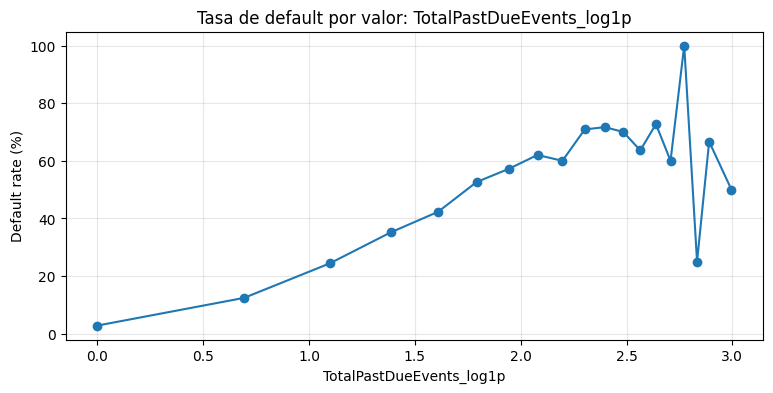

In [64]:
# ¿Cómo aumenta la tasa de default cuando aumenta cada variable?
# Para variables continuas utilizamos deciles.
# Para variables discretas (conteos, binarias, etc.) agrupamos por su valor.

def default_rate_by_bins(
    df: pd.DataFrame,
    feature: str,
    target: str = TARGET,
    q: int = 10,
    max_unique_discrete: int = 20,
) -> tuple[pd.DataFrame, str]:
    """
    Calcula la tasa de default según una variable.

    - Variables continuas  -> agrupación por cuantiles (qcut).
    - Variables discretas  -> agrupación por valor.
    """

    temp = df[[feature, target]].copy()

    # Número de valores distintos
    n_unique = temp[feature].nunique(dropna=True)

    # ------------------------------------------------------------------
    # Variable discreta
    # ------------------------------------------------------------------
    if n_unique <= max_unique_discrete:

        result = (
            temp
            .groupby(feature, observed=True)
            .agg(
                n=(target, "size"),
                default_rate=(target, "mean"),
            )
            .reset_index()
            .rename(columns={feature: "bin"})
        )

        result["feature_min"] = result["bin"]
        result["feature_max"] = result["bin"]

        grouping_type = "discrete"

    # ------------------------------------------------------------------
    # Variable continua
    # ------------------------------------------------------------------
    else:

        temp["bin"] = pd.qcut(
            temp[feature],
            q=q,
            duplicates="drop",
        )

        result = (
            temp
            .groupby("bin", observed=True)
            .agg(
                n=(target, "size"),
                default_rate=(target, "mean"),
                feature_min=(feature, "min"),
                feature_max=(feature, "max"),
            )
            .reset_index()
        )

        grouping_type = "continuous"

    result["default_rate_pct"] = 100 * result["default_rate"]

    return result, grouping_type


# ================================================================
# Visualización
# ================================================================

for feature in FINAL_FEATURES:

    dr, grouping_type = default_rate_by_bins(train_fe, feature)

    display(dr)

    plt.figure(figsize=(9, 4))

    if grouping_type == "continuous":

        plt.plot(
            range(len(dr)),
            dr["default_rate_pct"],
            marker="o",
        )

        plt.xticks(range(len(dr)))
        plt.xlabel("Decil de la variable")
        plt.title(f"Tasa de default por deciles: {feature}")

    else:

        plt.plot(
            dr["bin"],
            dr["default_rate_pct"],
            marker="o",
        )

        plt.xlabel(feature)
        plt.title(f"Tasa de default por valor: {feature}")

    plt.ylabel("Default rate (%)")
    plt.grid(alpha=0.3)

    plt.show()

En general, se observa una relación clara entre los distintos grupos de cada variable y la tasa de *default*. 
A medida que se avanza entre los deciles (o entre las categorías en el caso de variables discretas), 
la probabilidad de impago varía de forma consistente, lo que indica que las variables contienen información
relevante para discriminar entre clientes de mayor y menor riesgo y, por tanto,
resultan adecuadas para el desarrollo de modelos predictivos.


## 10. Correlaciones

Calculamos dos tipos:

- **Pearson**: relación lineal.
- **Spearman**: relación monótona, más robusta ante outliers y no linealidades.

También miramos la correlación absoluta con el target. Esto no decide por sí solo qué variables usar, pero ayuda a entender qué variables están más relacionadas con el evento de mora.

In [65]:
feature_cols_for_corr = [c for c in train_fe.columns if c != TARGET]

corr_pearson = train_fe[[TARGET] + feature_cols_for_corr].corr(method="pearson")
corr_spearman = train_fe[[TARGET] + feature_cols_for_corr].corr(method="spearman")

target_corr = pd.DataFrame({
    "feature": feature_cols_for_corr,
    "pearson_with_target": corr_pearson.loc[feature_cols_for_corr, TARGET].values,
    "spearman_with_target": corr_spearman.loc[feature_cols_for_corr, TARGET].values,
})

target_corr["abs_pearson"] = target_corr["pearson_with_target"].abs()
target_corr["abs_spearman"] = target_corr["spearman_with_target"].abs()

target_corr.sort_values("abs_spearman", ascending=False).head(20)

,feature,pearson_with_target,spearman_with_target,abs_pearson,abs_spearman
6,NumberOfTimes90DaysLate,0.3158,0.3366,0.3158,0.3366
15,TotalPastDueEvents,0.3917,0.3361,0.3917,0.3361
25,TotalPastDueEvents_log1p,0.3878,0.3361,0.3878,0.3361
17,Has90DaysLate,0.3340,0.3340,0.3340,0.3340
16,HasAnyPastDue,0.3108,0.3108,0.3108,0.3108
8,NumberOfTime60-89DaysPastDueNotWorse,0.2709,0.2703,0.2709,0.2703
2,NumberOfTime30-59DaysPastDueNotWorse,0.2696,0.2471,0.2696,0.2471
0,RevolvingUtilizationOfUnsecuredLines,-0.0004,0.2403,0.0004,0.2403
20,RevolvingUtilizationOfUnsecuredLines_log1p,0.1859,0.2403,0.1859,0.2403
1,age,-0.1165,-0.1181,0.1165,0.1181


<Figure size 2000x2000 with 0 Axes>

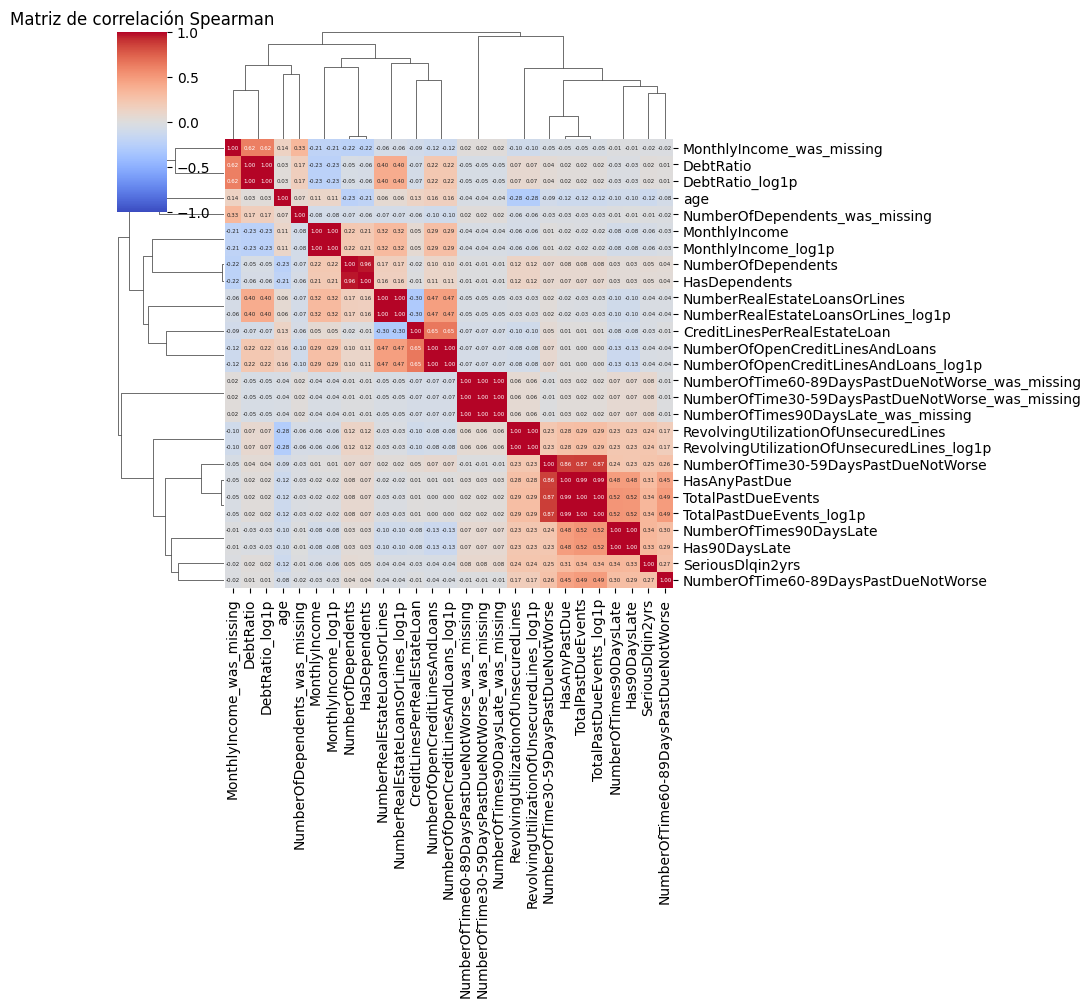

In [74]:
# Heatmap de correlación Spearman
plot_cols = train_fe.columns

corr = train_fe[plot_cols].corr(method="spearman")

plt.figure(figsize=(20, 20))

sns.clustermap(
    corr,
    annot=True,      # Escribe el número
    fmt=".2f",       # Dos decimales
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 4}
)

plt.title("Matriz de correlación Spearman")
plt.show()

In [ ]:
def high_correlation_pairs(corr_matrix: pd.DataFrame, threshold: float = 0.90) -> pd.DataFrame:
    """Devuelve pares de variables con correlación absoluta superior al umbral."""
    pairs = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            value = corr_matrix.iloc[i, j]
            if abs(value) >= threshold:
                pairs.append({
                    "feature_1": cols[i],
                    "feature_2": cols[j],
                    "correlation": value,
                    "abs_correlation": abs(value),
                })
    return pd.DataFrame(pairs).sort_values("abs_correlation", ascending=False)

high_corr = high_correlation_pairs(train_fe[feature_cols_for_corr].corr(method="spearman"), threshold=0.90)
high_corr

## 11. Mutual Information

La correlación mide relaciones lineales o monótonas. `Mutual Information` puede detectar relaciones más generales entre una variable y el target. No presupone linealidad.

In [ ]:
# Mutual information requiere que no haya NaN. Ya imputamos previamente.
X_mi = train_fe[FINAL_FEATURES].astype(float)
y_mi = train_fe[TARGET].astype(int)

mi_values = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_table = pd.DataFrame({"feature": FINAL_FEATURES, "mutual_information": mi_values})
mi_table = mi_table.sort_values("mutual_information", ascending=False)
mi_table.head(20)

In [ ]:
plt.figure(figsize=(10, 6))
top_mi = mi_table.head(20).iloc[::-1]
plt.barh(top_mi["feature"], top_mi["mutual_information"])
plt.title("Top 20 variables por Mutual Information con el target")
plt.xlabel("Mutual Information")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 12. PCA

PCA no se usará necesariamente en el modelo final, porque reduce interpretabilidad. Sin embargo, es útil para:

- detectar redundancia entre variables;
- visualizar si hay separación natural entre clases;
- entender cuánta varianza se concentra en pocos componentes.

Como PCA es sensible a escala, usamos `StandardScaler`.

In [ ]:
# Escalado de features para PCA.
pca_scaler = StandardScaler()
X_scaled = pca_scaler.fit_transform(train_fe[FINAL_FEATURES].astype(float))

pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
})
explained["cumulative_explained_variance"] = explained["explained_variance_ratio"].cumsum()

explained.head(15)

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(explained["component"], explained["cumulative_explained_variance"], marker="o")
plt.axhline(0.80, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Visualización 2D de los dos primeros componentes.
# Muestreamos para que el gráfico sea legible y rápido.
plot_sample = train_fe.sample(n=min(10000, len(train_fe)), random_state=RANDOM_STATE).index

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[plot_sample, 0],
    X_pca[plot_sample, 1],
    c=train_fe.loc[plot_sample, TARGET],
    alpha=0.35,
    s=8,
)
plt.title("PCA: proyección en las dos primeras componentes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="SeriousDlqin2yrs")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Loadings: peso de cada variable en cada componente.
loadings = pd.DataFrame(
    pca.components_.T,
    index=FINAL_FEATURES,
    columns=[f"PC{i}" for i in range(1, len(FINAL_FEATURES) + 1)]
)

# Variables con más peso absoluto en las primeras componentes.
for pc in ["PC1", "PC2", "PC3"]:
    print("\n", pc)
    display(loadings[pc].abs().sort_values(ascending=False).head(10).to_frame("abs_loading"))

## 13. Guardado de datasets y objetos

Guardamos:

- `preprocessed_train.csv`
- `preprocessed_prod.csv`
- lista de features finales
- imputador KNN
- límites de clipping
- resúmenes EDA

Los notebooks siguientes parten de estos ficheros para asegurar reproducibilidad.

In [ ]:
# Validaciones finales antes de guardar.
assert train_fe[TARGET].isna().sum() == 0, "El target de construcción no debe tener NaN."
assert prod_fe[TARGET].isna().sum() == len(prod_fe), "El target de producción debe permanecer vacío antes de predecir."
assert train_fe[FINAL_FEATURES].isna().sum().sum() == 0, "Quedan NaN en features de construcción."
assert prod_fe[FINAL_FEATURES].isna().sum().sum() == 0, "Quedan NaN en features de producción."

train_fe.to_csv(OUTPUT_DIR / "preprocessed_train.csv", index=False)
prod_fe.to_csv(OUTPUT_DIR / "preprocessed_prod.csv", index=False)

joblib.dump({
    "target": TARGET,
    "original_features": FEATURES,
    "final_features": FINAL_FEATURES,
    "missing_flag_cols": missing_flag_cols,
    "imputer": knn_imputer,
    "clipping_limits": clipping_limits,
    "pca_scaler": pca_scaler,
    "pca": pca,
}, OBJECTS_DIR / "preprocessing_objects.joblib")

mi_table.to_csv(OUTPUT_DIR / "mutual_information.csv", index=False)
target_corr.to_csv(OUTPUT_DIR / "target_correlations.csv", index=False)
high_corr.to_csv(OUTPUT_DIR / "high_correlations.csv", index=False)
explained.to_csv(OUTPUT_DIR / "pca_explained_variance.csv", index=False)

print("Ficheros guardados en:", OUTPUT_DIR.resolve())
print("Objetos guardados en:", OBJECTS_DIR.resolve())

## 14. Conclusiones del EDA y preprocesado

Puntos que deberías comentar en la memoria o presentación:

1. El problema está desbalanceado: hay muchos más clientes sin morosidad grave que con morosidad grave.
2. Las variables de retrasos pasados son candidatas muy fuertes para predecir el riesgo futuro.
3. Hay variables con colas extremadamente largas, especialmente ratios financieros. Por eso se ha aplicado clipping conservador.
4. Los valores perdidos se han tratado con KNN, pero conservando flags de ausencia para no perder información potencialmente relevante.
5. PCA se usa como análisis, no como transformación principal, porque el objetivo de la práctica incluye XAI y conviene conservar variables interpretables.
6. El dataset preprocesado queda listo para entrenar modelos de caja negra: red neuronal y aprendizaje por refuerzo contextual.